In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Loading

In [2]:
miRNA_index = {
    5: 'MIR4426',
    12: 'MIR3655',
    40: 'MIR222'
}

In [3]:
ind_MF_d3_5_df = pd.read_csv("Results/d3/ind_MF_5.csv", index_col=0)
int_MF_d3_5_df = pd.read_csv("Results/d3/int_MF_5.csv", index_col=0)
BD_d3_5_df = pd.read_csv("Results/d3/BD_5.csv", index_col=0)
TE_d3_5_df = pd.read_csv("Results/d3/TE_5.csv", index_col=0)

ind_MF_d2_5_df = pd.read_csv("Results/d2/ind_MF_5.csv", index_col=0)
int_MF_d2_5_df = pd.read_csv("Results/d2/int_MF_5.csv", index_col=0)
BD_d2_5_df = pd.read_csv("Results/d2/BD_5.csv", index_col=0)
TE_d2_5_df = pd.read_csv("Results/d2/TE_5.csv", index_col=0)

corr_5_df = pd.read_csv("Results/corr_5.csv", index_col=0)

In [4]:
ind_MF_d3_12_df = pd.read_csv("Results/d3/ind_MF_12.csv", index_col=0)
int_MF_d3_12_df = pd.read_csv("Results/d3/int_MF_12.csv", index_col=0)
BD_d3_12_df = pd.read_csv("Results/d3/BD_12.csv", index_col=0)
TE_d3_12_df = pd.read_csv("Results/d3/TE_12.csv", index_col=0)

corr_12_df = pd.read_csv("Results/corr_12.csv", index_col=0)

In [5]:
ind_MF_d3_40_df = pd.read_csv("Results/d3/ind_MF_40.csv", index_col=0)
int_MF_d3_40_df = pd.read_csv("Results/d3/int_MF_40.csv", index_col=0)
BD_d3_40_df = pd.read_csv("Results/d3/BD_40.csv", index_col=0)
TE_d3_40_df = pd.read_csv("Results/d3/TE_40.csv", index_col=0)

corr_40_df = pd.read_csv("Results/corr_40.csv", index_col=0)

In [6]:
fano_pcRNA_df = pd.read_csv("Results/fano_pcRNA.csv", index_col=0)
fano_miRNA_df = pd.read_csv("Results/fano_miRNA.csv", index_col=0)

In [7]:
ind_df_list = [ind_MF_d3_5_df, ind_MF_d3_12_df, ind_MF_d3_40_df]
int_df_list = [int_MF_d3_5_df, int_MF_d3_12_df, int_MF_d3_40_df]
corr_df_list = [corr_5_df, corr_12_df, corr_40_df]
idx_list = [5, 12, 40]

# Interacting pairs

In [19]:
G = ind_df_list[0].shape[0]
total = 0
for idx, ind_df in zip(idx_list, ind_df_list):
    mask = (ind_df == "INFEASIBLE")
    num_int = int(mask.values.sum())
    total += num_int
    print(f"{miRNA_index[idx]}: {round(100 * num_int / G, 1)}% interacting pairs ({num_int} / {G})")

print(f"\nAll miRNA combined: {round(100 * total / (3 * G))}% interacting pairs ({total} / {3 * G})")   

MIR4426: 23.3% interacting pairs (2406 / 10307)
MIR3655: 9.3% interacting pairs (960 / 10307)
MIR222: 28.5% interacting pairs (2937 / 10307)

All miRNA combined: 20% interacting pairs (6303 / 30921)


In [20]:
mask = (ind_MF_d2_5_df == "INFEASIBLE")
num_int = int(mask.values.sum())
print(f"(d = 2) {miRNA_index[5]}: {round(100 * num_int / G, 1)}% interacting pairs ({num_int} / {G})")

(d = 2) MIR4426: 21.8% interacting pairs (2247 / 10307)


# Correlation Scatters

Analytic method can produce correlation estimates outside of [-1, 1] range

Clamp plot to [-1, 1]

## Points

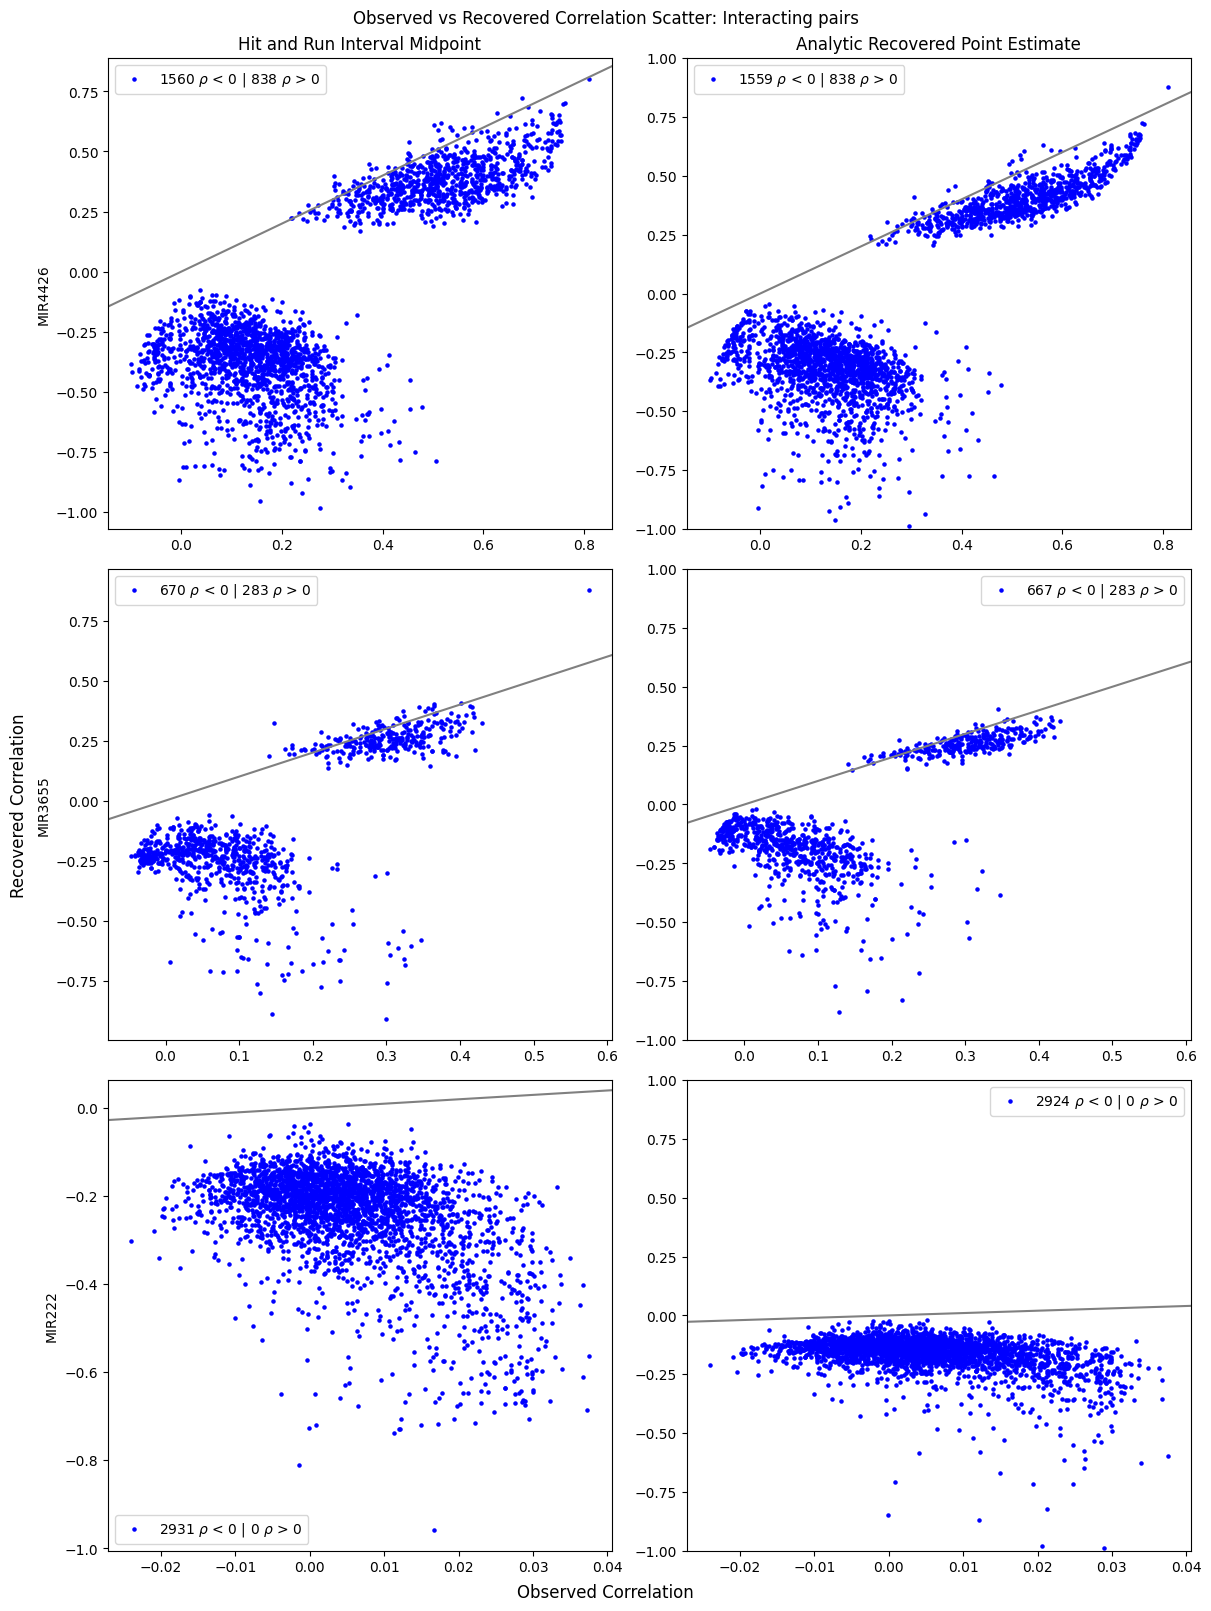

In [25]:
fig, axs = plt.subplots(3, 2, figsize=(12, 16), constrained_layout=True)

for i, (idx, ind_df, int_df, corr_df) in enumerate(zip(idx_list, ind_df_list, int_df_list, corr_df_list)):

    # name
    miRNA = miRNA_index[idx]

    # HAR
    lb = int_df[f'{miRNA}_d3_N1000_c95_mc95_HAR_corr_min']
    ub = int_df[f'{miRNA}_d3_N1000_c95_mc95_HAR_corr_max']
    mid = (lb + ub) / 2

    # OB & AL
    mask = (ind_df == "INFEASIBLE").values.squeeze()
    OB = corr_df[f'{miRNA}_c95_OB'][mask]
    AL = corr_df[f'{miRNA}_c95_AL'][mask]

    # stats
    HAR_neg = int((mid < 0).sum())
    HAR_pos = int((mid > 0).sum())
    AL_neg = int((AL < 0).sum())
    AL_pos = int((AL > 0).sum())

    # plot
    axs[i, 0].scatter(OB, mid, color="blue", s=5, label=fr"{HAR_neg} $\rho$ < 0 | {HAR_pos} $\rho$ > 0")
    axs[i, 1].scatter(OB, AL, color="blue", s=5, label=fr"{AL_neg} $\rho$ < 0 | {AL_pos} $\rho$ > 0")

    axs[i, 1].set_ylim(bottom=-1, top=1)

    m = np.mean(OB)
    axs[i, 0].axline([m]*2, [m+0.01]*2, color="grey")
    axs[i, 1].axline([m]*2, [m+0.01]*2, color="grey")

    axs[i, 0].set_ylabel(miRNA)

    axs[i, 0].legend()
    axs[i, 1].legend()

axs[0, 0].set_title("Hit and Run Interval Midpoint")
axs[0, 1].set_title("Analytic Recovered Point Estimate")
fig.supxlabel("Observed Correlation")
fig.supylabel("Recovered Correlation")
fig.suptitle("Observed vs Recovered Correlation Scatter: Interacting pairs")
plt.show()

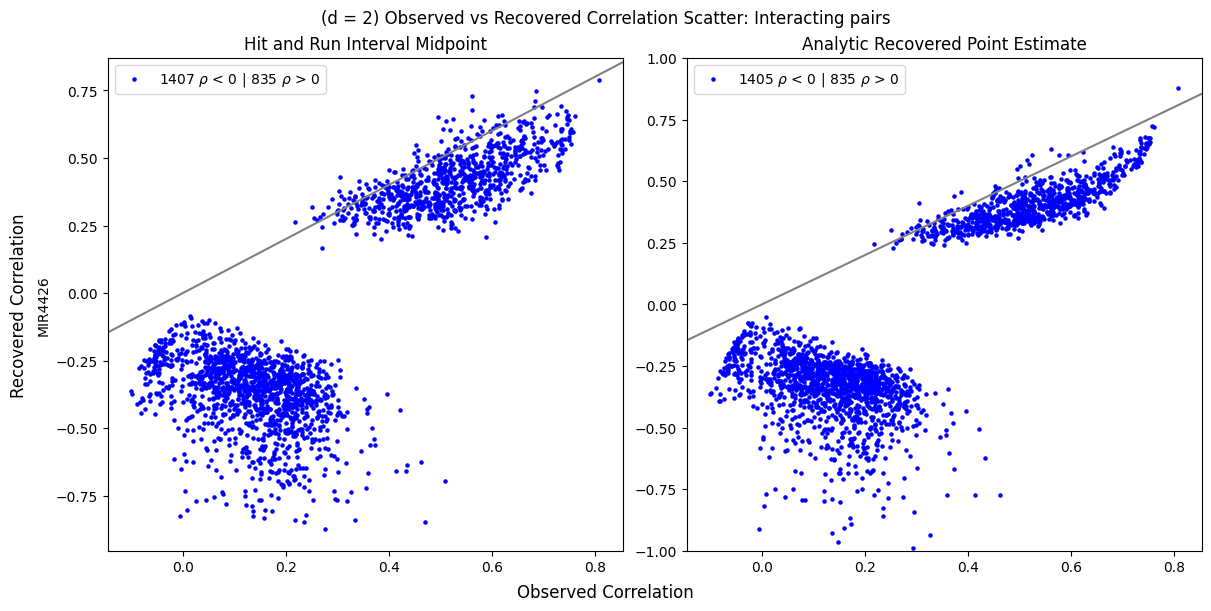

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True, squeeze=False)

# data
ind_df = ind_MF_d2_5_df
int_df = int_MF_d2_5_df
corr_df = corr_5_df

# name
miRNA = miRNA_index[5]

# HAR
lb = int_df[f'{miRNA}_d2_N1000_c95_mc95_HAR_corr_min']
ub = int_df[f'{miRNA}_d2_N1000_c95_mc95_HAR_corr_max']
mid = (lb + ub) / 2

# OB & AL
mask = (ind_df == "INFEASIBLE").values.squeeze()
OB = corr_df[f'{miRNA}_c95_OB'][mask]
AL = corr_df[f'{miRNA}_c95_AL'][mask]

# stats
HAR_neg = int((mid < 0).sum())
HAR_pos = int((mid > 0).sum())
AL_neg = int((AL < 0).sum())
AL_pos = int((AL > 0).sum())

# plot
axs[0, 0].scatter(OB, mid, color="blue", s=5, label=fr"{HAR_neg} $\rho$ < 0 | {HAR_pos} $\rho$ > 0")
axs[0, 1].scatter(OB, AL, color="blue", s=5, label=fr"{AL_neg} $\rho$ < 0 | {AL_pos} $\rho$ > 0")

axs[0, 1].set_ylim(bottom=-1, top=1)

m = np.mean(OB)
axs[0, 0].axline([m]*2, [m+0.01]*2, color="grey")
axs[0, 1].axline([m]*2, [m+0.01]*2, color="grey")

axs[0, 0].set_ylabel(miRNA)

axs[0, 0].legend()
axs[0, 1].legend()

axs[0, 0].set_title("Hit and Run Interval Midpoint")
axs[0, 1].set_title("Analytic Recovered Point Estimate")
fig.supxlabel("Observed Correlation")
fig.supylabel("Recovered Correlation")
fig.suptitle("(d = 2) Observed vs Recovered Correlation Scatter: Interacting pairs")
plt.show()

## Intervals

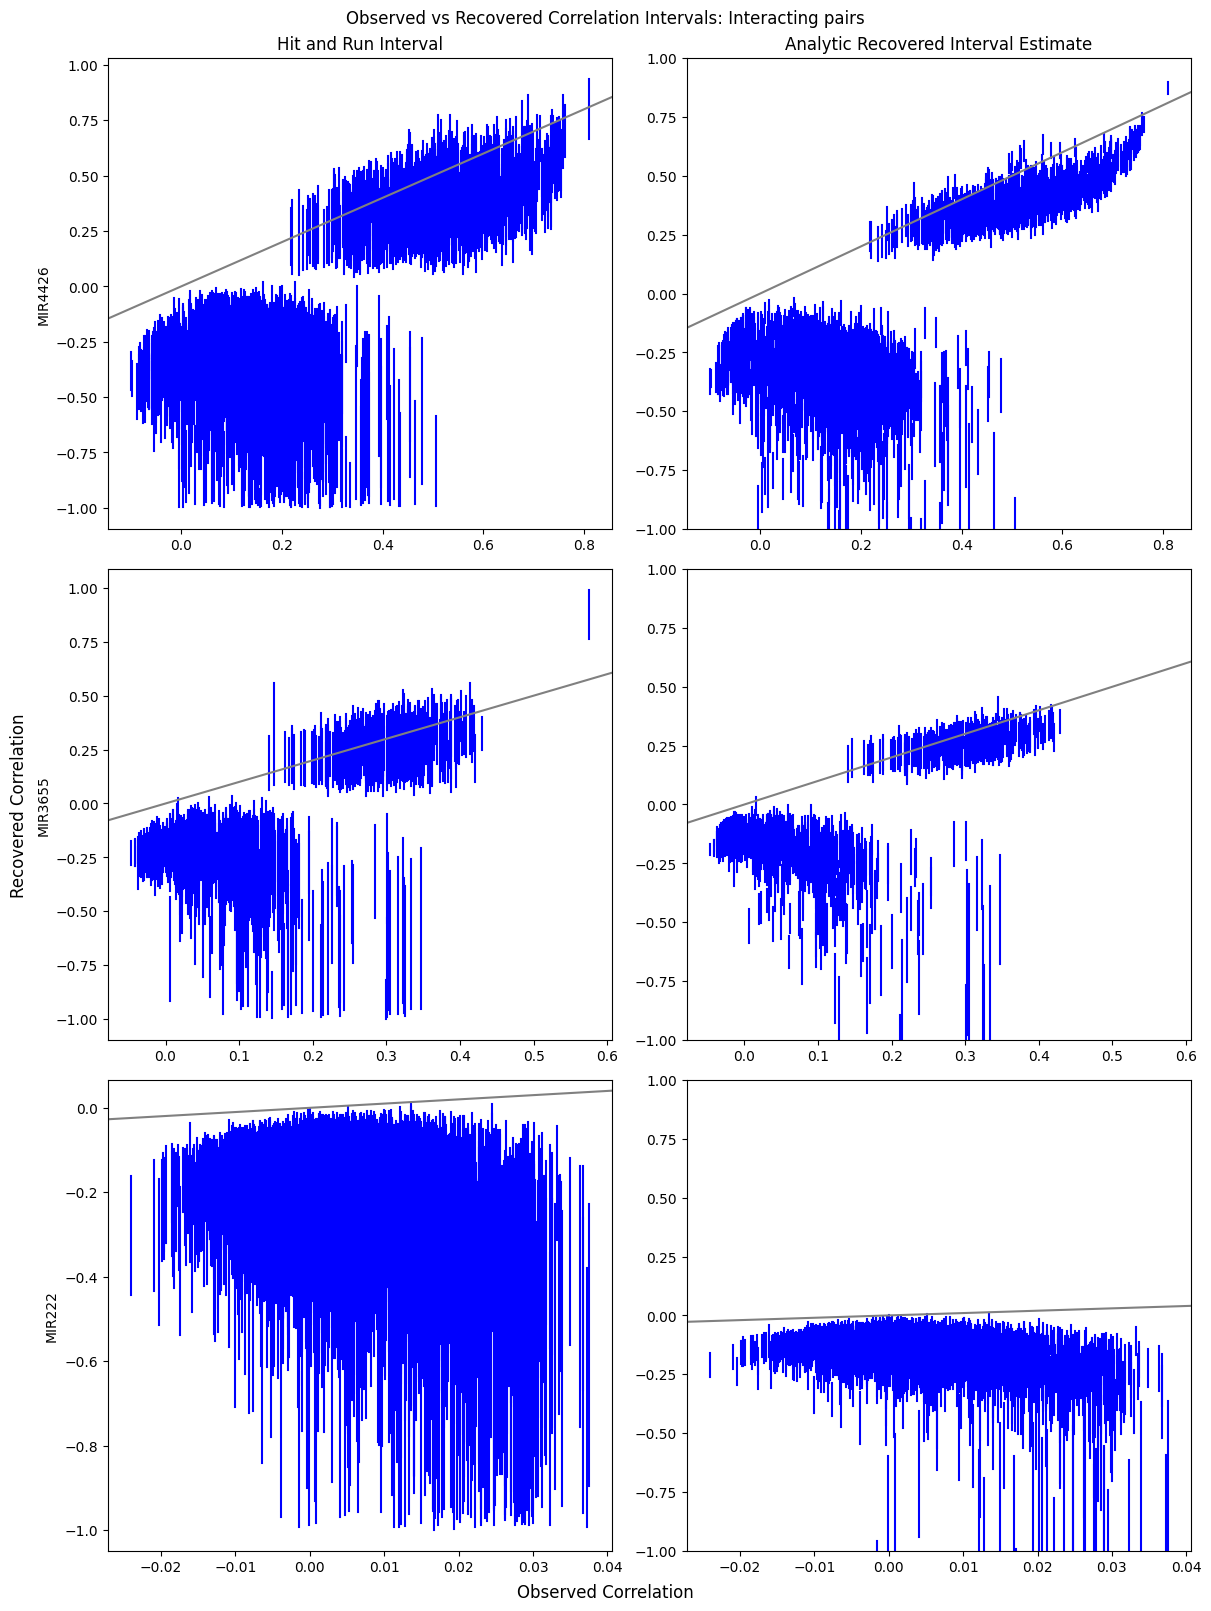

In [28]:
fig, axs = plt.subplots(3, 2, figsize=(12, 16), constrained_layout=True)

for i, (idx, ind_df, int_df, corr_df) in enumerate(zip(idx_list, ind_df_list, int_df_list, corr_df_list)):

    # name
    miRNA = miRNA_index[idx]

    # HAR
    HAR_lb = int_df[f'{miRNA}_d3_N1000_c95_mc95_HAR_corr_min']
    HAR_ub = int_df[f'{miRNA}_d3_N1000_c95_mc95_HAR_corr_max']

    # OB & AL
    mask = (ind_df == "INFEASIBLE").values.squeeze()
    OB = corr_df[f'{miRNA}_c95_OB'][mask]
    AL_lb = corr_df[f'{miRNA}_c95_AL_min'][mask]
    AL_ub = corr_df[f'{miRNA}_c95_AL_max'][mask]

    # plot
    axs[i, 0].plot([OB]*2, [HAR_lb, HAR_ub], color="blue")
    axs[i, 1].plot([OB]*2, [AL_lb, AL_ub], color="blue")

    axs[i, 1].set_ylim(bottom=-1, top=1)

    m = np.mean(OB)
    axs[i, 0].axline([m]*2, [m+0.01]*2, color="grey")
    axs[i, 1].axline([m]*2, [m+0.01]*2, color="grey")

    axs[i, 0].set_ylabel(miRNA)

axs[0, 0].set_title("Hit and Run Interval")
axs[0, 1].set_title("Analytic Recovered Interval Estimate")
fig.supxlabel("Observed Correlation")
fig.supylabel("Recovered Correlation")
fig.suptitle("Observed vs Recovered Correlation Intervals: Interacting pairs")
plt.show()

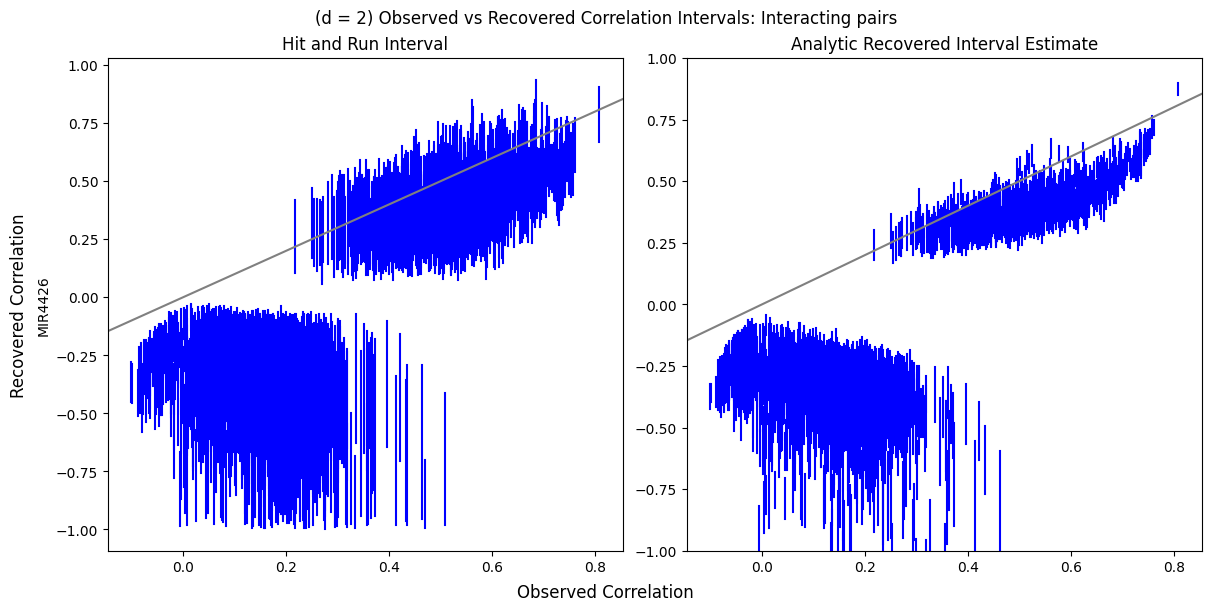

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True, squeeze=False)

# data
ind_df = ind_MF_d2_5_df
int_df = int_MF_d2_5_df
corr_df = corr_5_df

# name
miRNA = miRNA_index[5]

# HAR
HAR_lb = int_df[f'{miRNA}_d2_N1000_c95_mc95_HAR_corr_min']
HAR_ub = int_df[f'{miRNA}_d2_N1000_c95_mc95_HAR_corr_max']

# OB & AL
mask = (ind_df == "INFEASIBLE").values.squeeze()
OB = corr_df[f'{miRNA}_c95_OB'][mask]
AL_lb = corr_df[f'{miRNA}_c95_AL_min'][mask]
AL_ub = corr_df[f'{miRNA}_c95_AL_max'][mask]

# plot
axs[0, 0].plot([OB]*2, [HAR_lb, HAR_ub], color="blue")
axs[0, 1].plot([OB]*2, [AL_lb, AL_ub], color="blue")

axs[0, 1].set_ylim(bottom=-1, top=1)

m = np.mean(OB)
axs[0, 0].axline([m]*2, [m+0.01]*2, color="grey")
axs[0, 1].axline([m]*2, [m+0.01]*2, color="grey")

axs[0, 0].set_ylabel(miRNA)

axs[0, 0].set_title("Hit and Run Interval")
axs[0, 1].set_title("Analytic Recovered Interval Estimate")
fig.supxlabel("Observed Correlation")
fig.supylabel("Recovered Correlation")
fig.suptitle("(d = 2) Observed vs Recovered Correlation Intervals: Interacting pairs")
plt.show()

## Positive Correlation Investigation

Main results obtained for 20% mean capture

Show results for MIR4426 with 10% and 30% mean capture

See positive correlations are present across all, overall robust to changes in capture mean

In [15]:
ind_MF_capture_10_5_df = pd.read_csv("Capture-testing/Results-capture/ind_MF_capture_10_5.csv", index_col=0)
int_MF_capture_10_5_df = pd.read_csv("Capture-testing/Results-capture/int_MF_capture_10_5.csv", index_col=0)
corr_capture_10_5_df = pd.read_csv("Capture-testing/Results-capture/corr_capture_10_5.csv", index_col=0)

In [16]:
ind_MF_capture_30_5_df = pd.read_csv("Capture-testing/Results-capture/ind_MF_capture_30_5.csv", index_col=0)
int_MF_capture_30_5_df = pd.read_csv("Capture-testing/Results-capture/int_MF_capture_30_5.csv", index_col=0)
corr_capture_30_5_df = pd.read_csv("Capture-testing/Results-capture/corr_capture_30_5.csv", index_col=0)

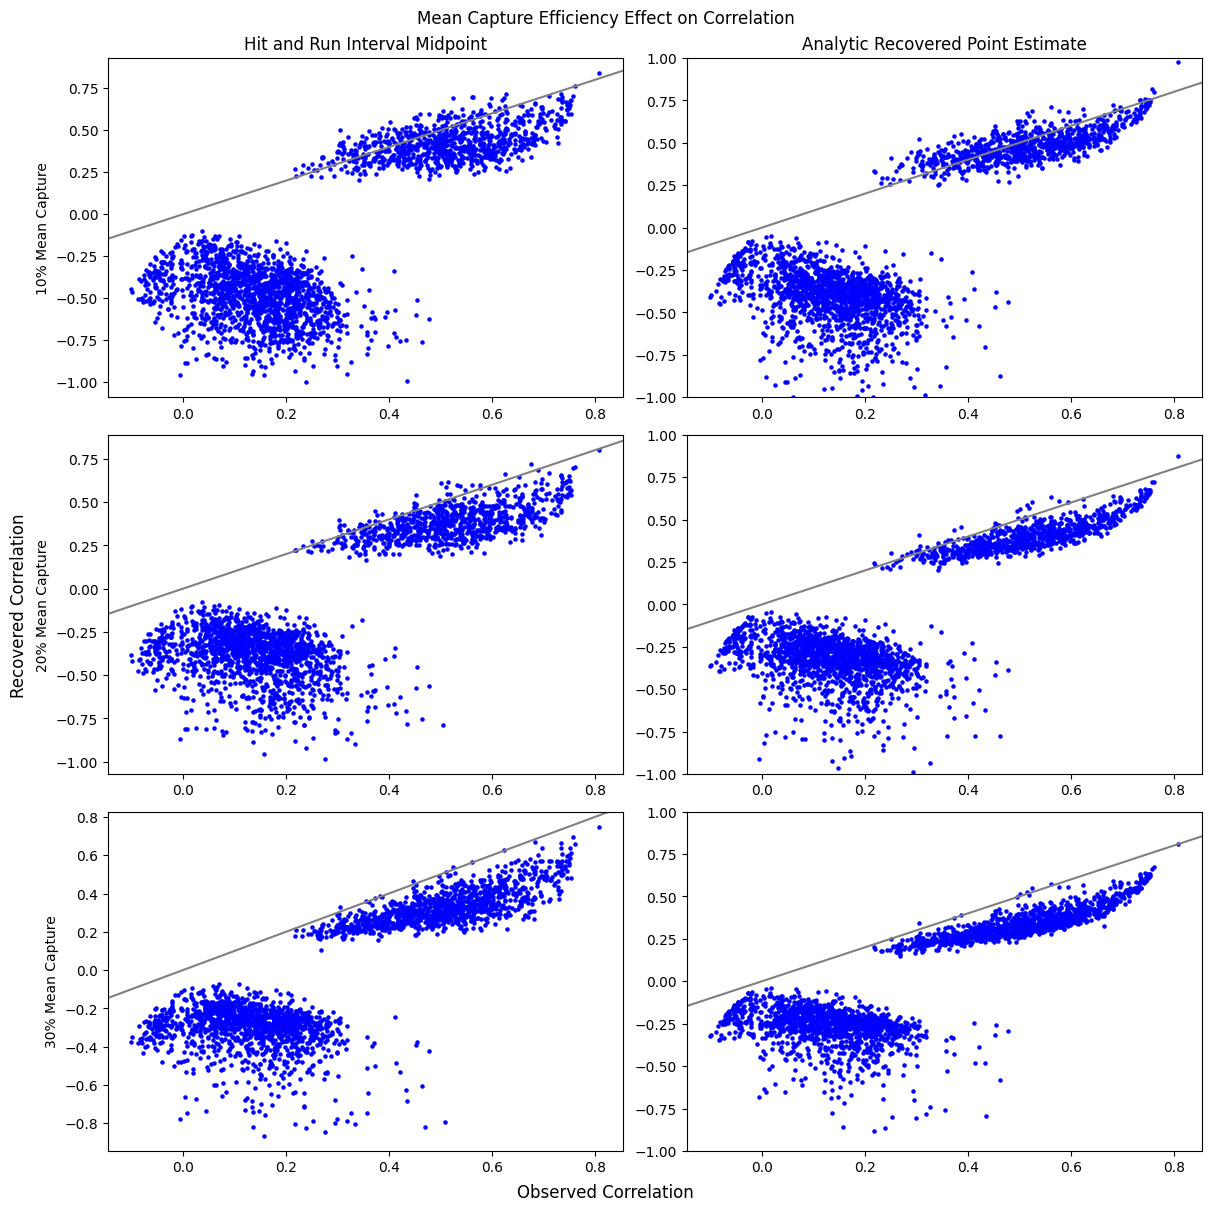

In [19]:
fig, axs = plt.subplots(3, 2, figsize=(12, 12), constrained_layout=True)

ind_df_capture_list = [ind_MF_capture_10_5_df, ind_MF_5_df, ind_MF_capture_30_5_df]
int_df_capture_list = [int_MF_capture_10_5_df, int_MF_5_df, int_MF_capture_30_5_df]
corr_df_capture_list = [corr_capture_10_5_df, corr_5_df, corr_capture_30_5_df]

# name
miRNA = miRNA_index[5]

for i, (ind_df, int_df, corr_df) in enumerate(zip(ind_df_capture_list, int_df_capture_list, corr_df_capture_list)):

    # HAR
    lb = int_df[f'{miRNA}_d3_N1000_c95_mc95_HAR_corr_min']
    ub = int_df[f'{miRNA}_d3_N1000_c95_mc95_HAR_corr_max']
    mid = (lb + ub) / 2

    # OB & AL
    mask = (ind_df == "INFEASIBLE").values.squeeze()
    OB = corr_df[f'{miRNA}_c95_OB'][mask]
    AL = corr_df[f'{miRNA}_c95_AL'][mask]

    # plot
    axs[i, 0].scatter(OB, mid, color="blue", s=5)
    axs[i, 1].scatter(OB, AL, color="blue", s=5)

    axs[i, 1].set_ylim(bottom=-1, top=1)

    m = np.mean(OB)
    axs[i, 0].axline([m]*2, [m+0.01]*2, color="grey")
    axs[i, 1].axline([m]*2, [m+0.01]*2, color="grey")

    axs[i, 0].set_ylabel(f"{[10, 20, 30][i]}% Mean Capture")

axs[0, 0].set_title("Hit and Run Interval Midpoint")
axs[0, 1].set_title("Analytic Recovered Point Estimate")
fig.supxlabel("Observed Correlation")
fig.supylabel("Recovered Correlation")
fig.suptitle("Mean Capture Efficiency Effect on Correlation")
plt.show()

## Feasibility illustration

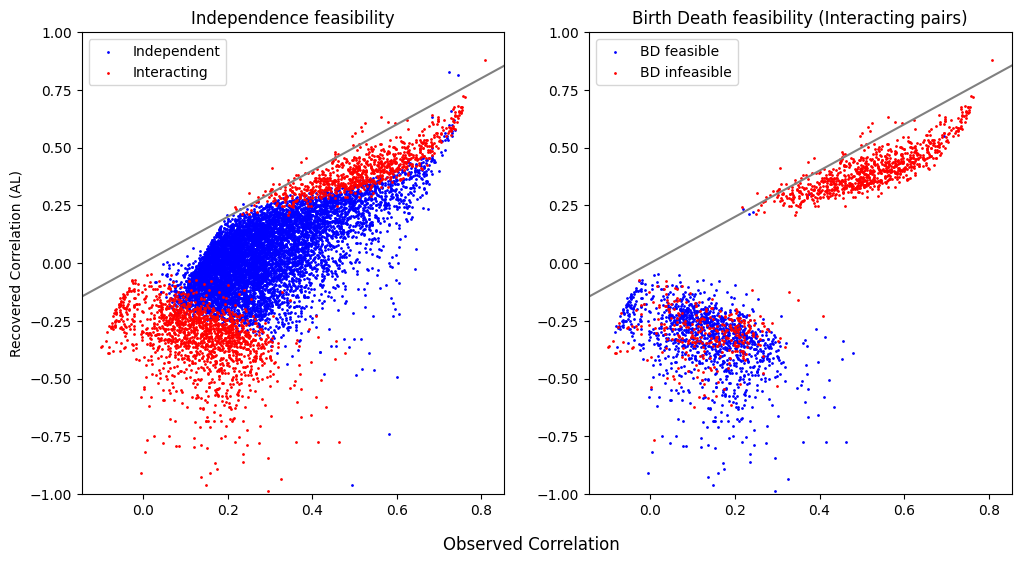

In [308]:
# feasibility selection
mask_MF = (ind_MF_d3_5_df == "INFEASIBLE").values.squeeze()
mask_BD = (BD_d3_5_df == "INFEASIBLE").values.squeeze()

# correlations
OB = corr_5_df['MIR4426_c95_OB']
AL = corr_5_df['MIR4426_c95_AL']

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# independent
axs[0].scatter(
    OB[~mask_MF],
    AL[~mask_MF],
    color="blue",
    s=1,
    alpha=1,
    label="Independent"
)

# interacting
axs[0].scatter(
    OB[mask_MF],
    AL[mask_MF],
    color="red",
    s=1,
    alpha=1,
    label="Interacting"
)

# interacting & birth death feasible
axs[1].scatter(
    OB[mask_MF][~mask_BD],
    AL[mask_MF][~mask_BD],
    color="blue",
    s=1,
    alpha=1,
    label="BD feasible"
)

# interacting & birth death infeasible
axs[1].scatter(
    OB[mask_MF][mask_BD],
    AL[mask_MF][mask_BD],
    color="red",
    s=1,
    alpha=1,
    label="BD infeasible"
)
axs[0].set_title("Independence feasibility")
axs[1].set_title("Birth Death feasibility (Interacting pairs)")
axs[0].set_ylabel("Recovered Correlation (AL)")
fig.supxlabel("Observed Correlation")
axs[0].axline([0, 0], [0.1, 0.1], color="grey")
axs[1].axline([0, 0], [0.1, 0.1], color="grey")
axs[0].set_ylim(bottom=-1, top=1)
axs[1].set_ylim(bottom=-1, top=1)
axs[0].legend()
axs[1].legend()
plt.show()

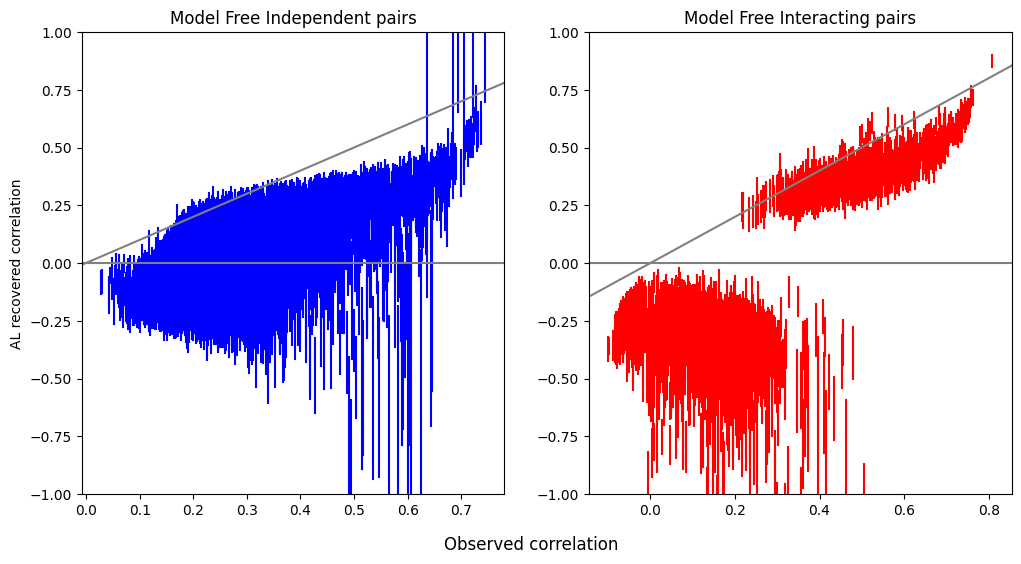

In [88]:
ind_df = ind_MF_d3_5_df
int_df = int_MF_d3_5_df
corr_df = corr_5_df

# name
miRNA = miRNA_index[5]

# HAR
HAR_lb = int_df[f'{miRNA}_d3_N1000_c95_mc95_HAR_corr_min']
HAR_ub = int_df[f'{miRNA}_d3_N1000_c95_mc95_HAR_corr_max']

# OB & AL
mask = (ind_df == "INFEASIBLE").values.squeeze()
OB = corr_df[f'{miRNA}_c95_OB']
AL_lb = corr_df[f'{miRNA}_c95_AL_min']
AL_ub = corr_df[f'{miRNA}_c95_AL_max']

# plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot([OB[~mask]]*2, [AL_lb[~mask], AL_ub[~mask]], color="blue")
axs[1].plot([OB[mask]]*2, [AL_lb[mask], AL_ub[mask]], color="red")

axs[0].set_ylim(bottom=-1, top=1)
axs[1].set_ylim(bottom=-1, top=1)

m = np.mean(OB)
axs[0].axline([m]*2, [m+0.01]*2, color="grey")
axs[0].axhline(0, color="grey")
axs[1].axline([m]*2, [m+0.01]*2, color="grey")
axs[1].axhline(0, color="grey")

axs[0].set_title("Model Free Independent pairs")
axs[1].set_title("Model Free Interacting pairs")

axs[0].set_ylabel("AL recovered correlation")
fig.supxlabel("Observed correlation")

plt.show()

- some independent feasible pairs (left) have correlation intervals that do not contain 0
    - these pairs were found to have a feasible point with 0 correlation
    - suggests AL intervals still tighter than optimization constraints

# Correlation Violin

Analytic recovered as only compute H&R recovered for interacting pairs

## MIR4426

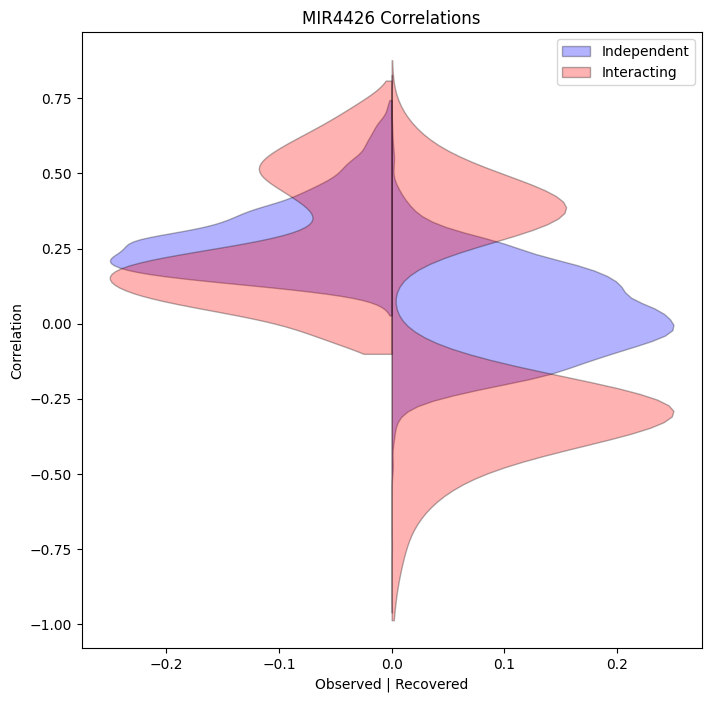

In [33]:
mask = (ind_MF_d3_5_df == "INFEASIBLE").values.squeeze()
OB = corr_5_df['MIR4426_c95_OB']
AL = corr_5_df['MIR4426_c95_AL']

OB_int = OB[mask]
OB_ind = OB[~mask]

AL_int = AL[mask]
AL_ind = AL[~mask]

OB_ind = OB_ind[OB_ind >= -1]
OB_ind = OB_ind[OB_ind <= 1]
OB_int = OB_int[OB_int >= -1]
OB_int = OB_int[OB_int <= 1]
AL_ind = AL_ind[AL_ind >= -1]
AL_ind = AL_ind[AL_ind <= 1]
AL_int = AL_int[AL_int >= -1]
AL_int = AL_int[AL_int <= 1]

fig, axs = plt.subplots(figsize=(8, 8))

# OB ind
vp = axs.violinplot(
    dataset=OB_ind,
    positions=[0],
    showextrema=False,
    side="low"
)
plt.setp(vp['bodies'], facecolor='blue', edgecolor='black', label="Independent")

# OB int
vp = axs.violinplot(
    dataset=OB_int,
    positions=[0],
    showextrema=False,
    side="low"
)
plt.setp(vp['bodies'], facecolor='red', edgecolor='black', label="Interacting")

# AL ind
vp = axs.violinplot(
    dataset=AL_ind,
    positions=[0],
    showextrema=False,
    side="high"
)
plt.setp(vp['bodies'], facecolor='blue', edgecolor='black')

# AL int
vp = axs.violinplot(
    dataset=AL_int,
    positions=[0],
    showextrema=False,
    side="high"
)
plt.setp(vp['bodies'], facecolor='red', edgecolor='black')

axs.set_ylabel("Correlation")
axs.set_xlabel("Observed | Recovered")
axs.set_title("MIR4426 Correlations")
axs.legend()
plt.show()

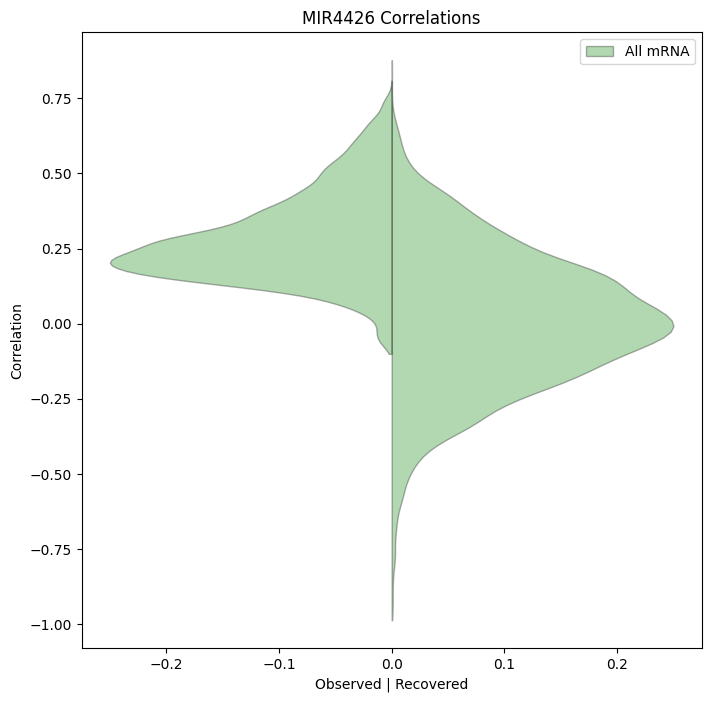

In [35]:
mask = (ind_MF_d3_5_df == "INFEASIBLE").values.squeeze()
OB = corr_5_df['MIR4426_c95_OB']
AL = corr_5_df['MIR4426_c95_AL']

OB_int = OB[mask]
OB_ind = OB[~mask]

AL_int = AL[mask]
AL_ind = AL[~mask]

OB = OB[OB >= -1]
OB = OB[OB <= 1]
AL = AL[AL >= -1]
AL = AL[AL <= 1]

fig, axs = plt.subplots(figsize=(8, 8))

# OB
vp = axs.violinplot(
    dataset=OB,
    positions=[0],
    showextrema=False,
    side="low"
)
plt.setp(vp['bodies'], facecolor='green', edgecolor='black', label="All mRNA")

# AL
vp = axs.violinplot(
    dataset=AL,
    positions=[0],
    showextrema=False,
    side="high"
)
plt.setp(vp['bodies'], facecolor='green', edgecolor='black')

axs.set_ylabel("Correlation")
axs.set_xlabel("Observed | Recovered")
axs.set_title("MIR4426 Correlations")
axs.legend()
plt.show()

## MIR3655

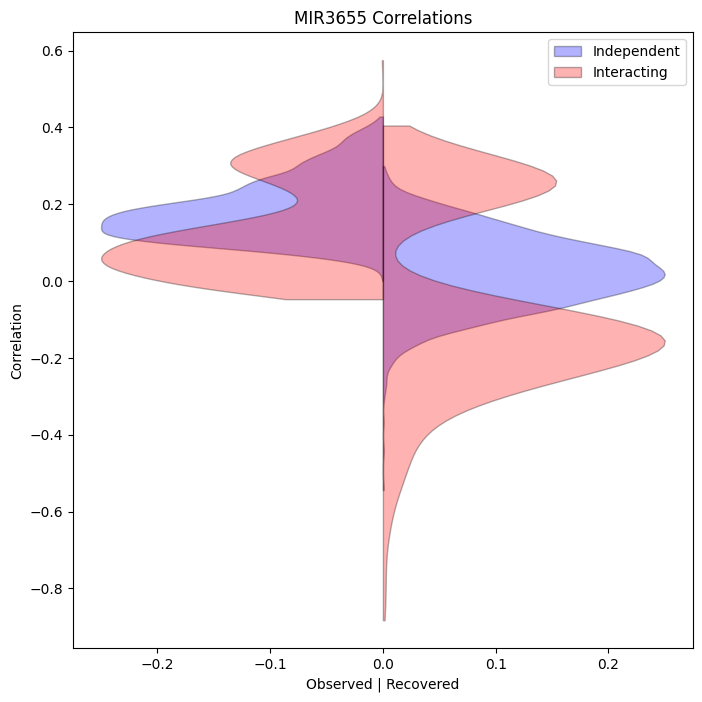

In [36]:
mask = (ind_MF_d3_12_df == "INFEASIBLE").values.squeeze()
OB = corr_12_df['MIR3655_c95_OB']
AL = corr_12_df['MIR3655_c95_AL']

OB_int = OB[mask]
OB_ind = OB[~mask]

AL_int = AL[mask]
AL_ind = AL[~mask]

OB_ind = OB_ind[OB_ind >= -1]
OB_ind = OB_ind[OB_ind <= 1]
OB_int = OB_int[OB_int >= -1]
OB_int = OB_int[OB_int <= 1]
AL_ind = AL_ind[AL_ind >= -1]
AL_ind = AL_ind[AL_ind <= 1]
AL_int = AL_int[AL_int >= -1]
AL_int = AL_int[AL_int <= 1]

fig, axs = plt.subplots(figsize=(8, 8))

# OB ind
vp = axs.violinplot(
    dataset=OB_ind,
    positions=[0],
    showextrema=False,
    side="low"
)
plt.setp(vp['bodies'], facecolor='blue', edgecolor='black', label="Independent")

# OB int
vp = axs.violinplot(
    dataset=OB_int,
    positions=[0],
    showextrema=False,
    side="low"
)
plt.setp(vp['bodies'], facecolor='red', edgecolor='black', label="Interacting")

# AL ind
vp = axs.violinplot(
    dataset=AL_ind,
    positions=[0],
    showextrema=False,
    side="high"
)
plt.setp(vp['bodies'], facecolor='blue', edgecolor='black')

# AL int
vp = axs.violinplot(
    dataset=AL_int,
    positions=[0],
    showextrema=False,
    side="high"
)
plt.setp(vp['bodies'], facecolor='red', edgecolor='black')

axs.set_ylabel("Correlation")
axs.set_xlabel("Observed | Recovered")
axs.set_title("MIR3655 Correlations")
axs.legend()
plt.show()

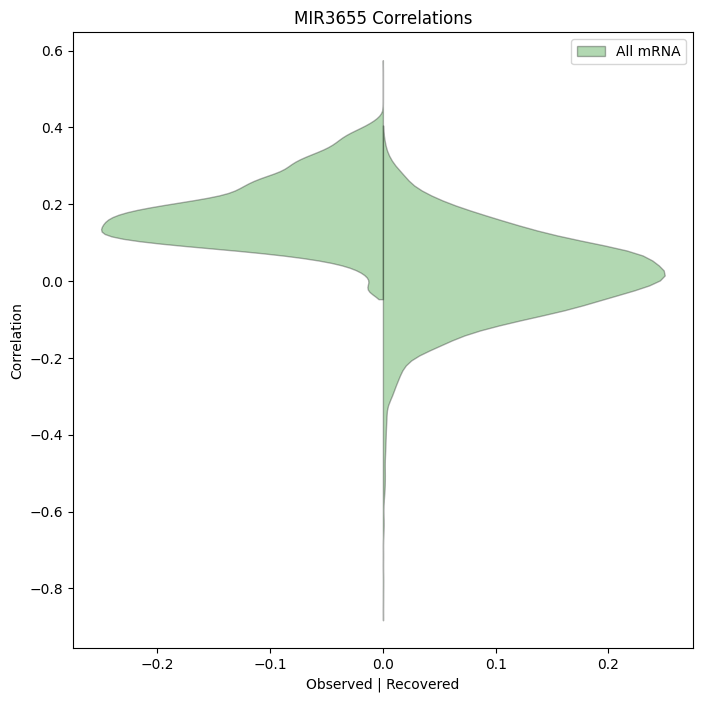

In [37]:
mask = (ind_MF_d3_12_df == "INFEASIBLE").values.squeeze()
OB = corr_12_df['MIR3655_c95_OB']
AL = corr_12_df['MIR3655_c95_AL']

OB_int = OB[mask]
OB_ind = OB[~mask]

AL_int = AL[mask]
AL_ind = AL[~mask]

OB = OB[OB >= -1]
OB = OB[OB <= 1]
AL = AL[AL >= -1]
AL = AL[AL <= 1]

fig, axs = plt.subplots(figsize=(8, 8))

# OB
vp = axs.violinplot(
    dataset=OB,
    positions=[0],
    showextrema=False,
    side="low"
)
plt.setp(vp['bodies'], facecolor='green', edgecolor='black', label="All mRNA")

# AL
vp = axs.violinplot(
    dataset=AL,
    positions=[0],
    showextrema=False,
    side="high"
)
plt.setp(vp['bodies'], facecolor='green', edgecolor='black')

axs.set_ylabel("Correlation")
axs.set_xlabel("Observed | Recovered")
axs.set_title("MIR3655 Correlations")
axs.legend()
plt.show()

## MIR222

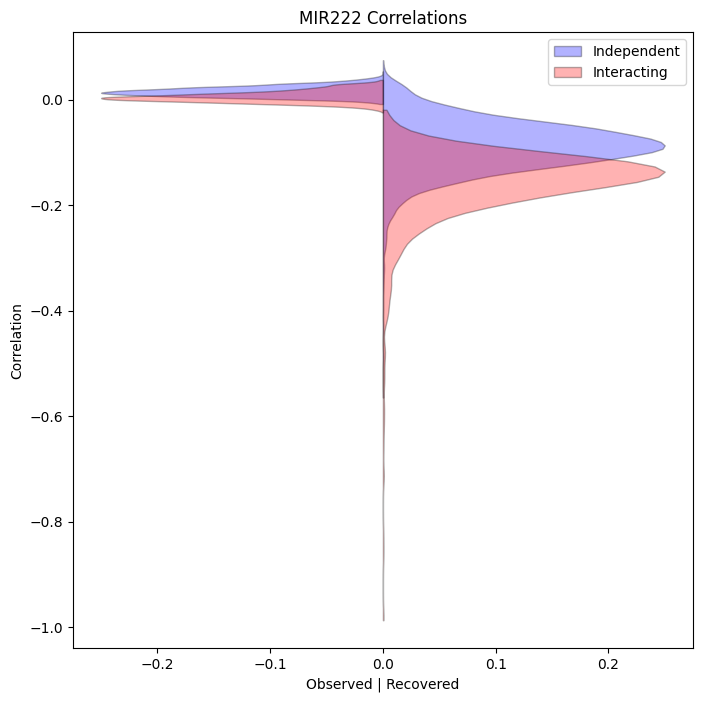

In [38]:
mask = (ind_MF_d3_40_df == "INFEASIBLE").values.squeeze()
OB = corr_40_df['MIR222_c95_OB']
AL = corr_40_df['MIR222_c95_AL']

OB_int = OB[mask]
OB_ind = OB[~mask]

AL_int = AL[mask]
AL_ind = AL[~mask]

OB_ind = OB_ind[OB_ind >= -1]
OB_ind = OB_ind[OB_ind <= 1]
OB_int = OB_int[OB_int >= -1]
OB_int = OB_int[OB_int <= 1]
AL_ind = AL_ind[AL_ind >= -1]
AL_ind = AL_ind[AL_ind <= 1]
AL_int = AL_int[AL_int >= -1]
AL_int = AL_int[AL_int <= 1]

fig, axs = plt.subplots(figsize=(8, 8))

# OB ind
vp = axs.violinplot(
    dataset=OB_ind,
    positions=[0],
    showextrema=False,
    side="low"
)
plt.setp(vp['bodies'], facecolor='blue', edgecolor='black', label="Independent")

# OB int
vp = axs.violinplot(
    dataset=OB_int,
    positions=[0],
    showextrema=False,
    side="low"
)
plt.setp(vp['bodies'], facecolor='red', edgecolor='black', label="Interacting")

# AL ind
vp = axs.violinplot(
    dataset=AL_ind,
    positions=[0],
    showextrema=False,
    side="high"
)
plt.setp(vp['bodies'], facecolor='blue', edgecolor='black')

# AL int
vp = axs.violinplot(
    dataset=AL_int,
    positions=[0],
    showextrema=False,
    side="high"
)
plt.setp(vp['bodies'], facecolor='red', edgecolor='black')

axs.set_ylabel("Correlation")
axs.set_xlabel("Observed | Recovered")
axs.set_title("MIR222 Correlations")
axs.legend()
plt.show()

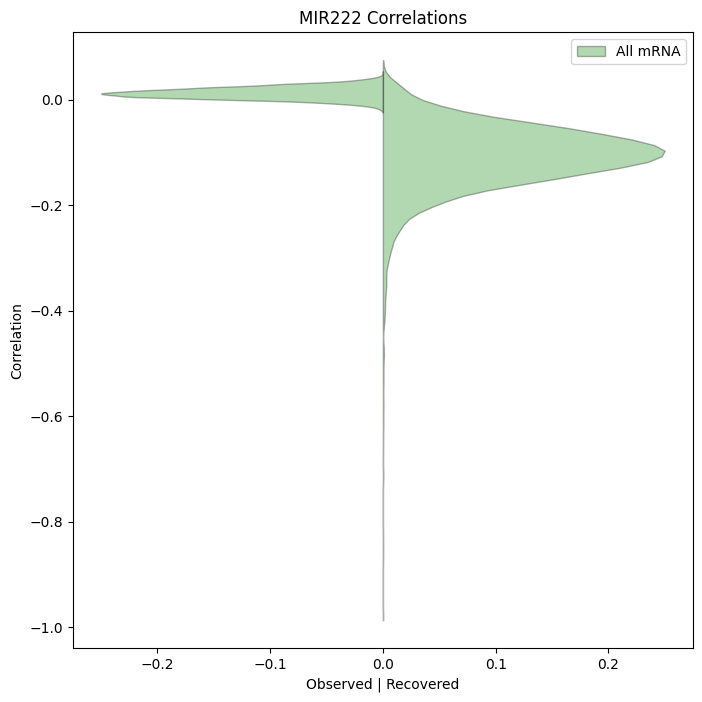

In [39]:
mask = (ind_MF_d3_40_df == "INFEASIBLE").values.squeeze()
OB = corr_40_df['MIR222_c95_OB']
AL = corr_40_df['MIR222_c95_AL']

OB_int = OB[mask]
OB_ind = OB[~mask]

AL_int = AL[mask]
AL_ind = AL[~mask]

OB = OB[OB >= -1]
OB = OB[OB <= 1]
AL = AL[AL >= -1]
AL = AL[AL <= 1]

fig, axs = plt.subplots(figsize=(8, 8))

# OB
vp = axs.violinplot(
    dataset=OB,
    positions=[0],
    showextrema=False,
    side="low"
)
plt.setp(vp['bodies'], facecolor='green', edgecolor='black', label="All mRNA")

# AL
vp = axs.violinplot(
    dataset=AL,
    positions=[0],
    showextrema=False,
    side="high"
)
plt.setp(vp['bodies'], facecolor='green', edgecolor='black')

axs.set_ylabel("Correlation")
axs.set_xlabel("Observed | Recovered")
axs.set_title("MIR222 Correlations")
axs.legend()
plt.show()

# Fano Factor

## Analytic method

### miRNA

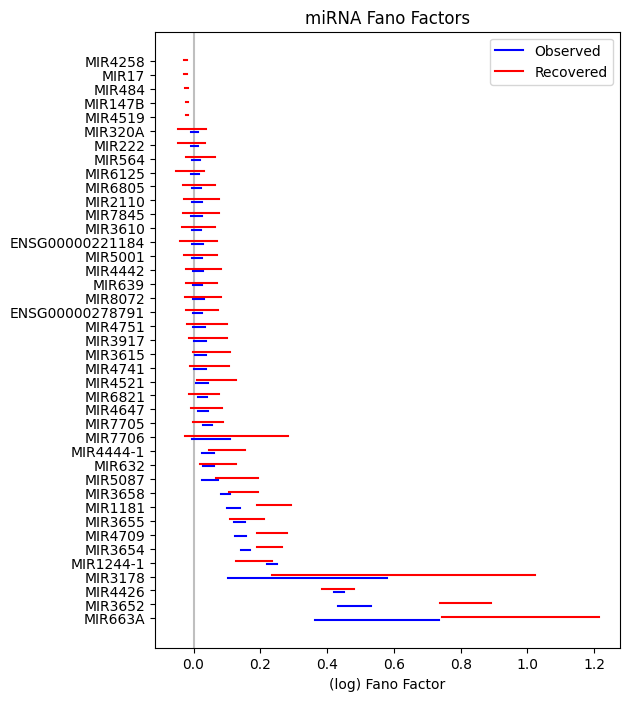

In [85]:
fig, axs = plt.subplots(figsize=(6, 8))

# sort by OB fano factor
fano_df = fano_miRNA_df.copy()
fano_df = fano_df.sort_values(by="c95_OB", ascending=False)

OB_fano_lb = np.log10(fano_df['c95_OB_min'])
OB_fano_ub = np.log10(fano_df['c95_OB_max'])

AL_fano_lb = np.log10(fano_df['c95_AL_min'])
AL_fano_ub = np.log10(fano_df['c95_AL_max'])

G = fano_df.shape[0]

axs.axvline(np.log10(1), color="grey", alpha=0.5)
axs.plot(
    [OB_fano_lb, OB_fano_ub],
    [
        [i - 0.1 for i in range(G)],
        [i - 0.1 for i in range(G)]
    ],
    color="blue"
);
axs.plot([], [], color="blue", label="Observed")
axs.plot(
    [AL_fano_lb, AL_fano_ub],
    [
        [i + 0.1 for i in range(G)],
        [i + 0.1 for i in range(G)]
    ],
    color="red"
);
axs.plot([], [], color="red", label="Recovered")

axs.set_xlabel("(log) Fano Factor")
axs.set_yticks(range(G))
axs.set_yticklabels(fano_df.index)
axs.set_title("miRNA Fano Factors")
axs.legend()
plt.show()

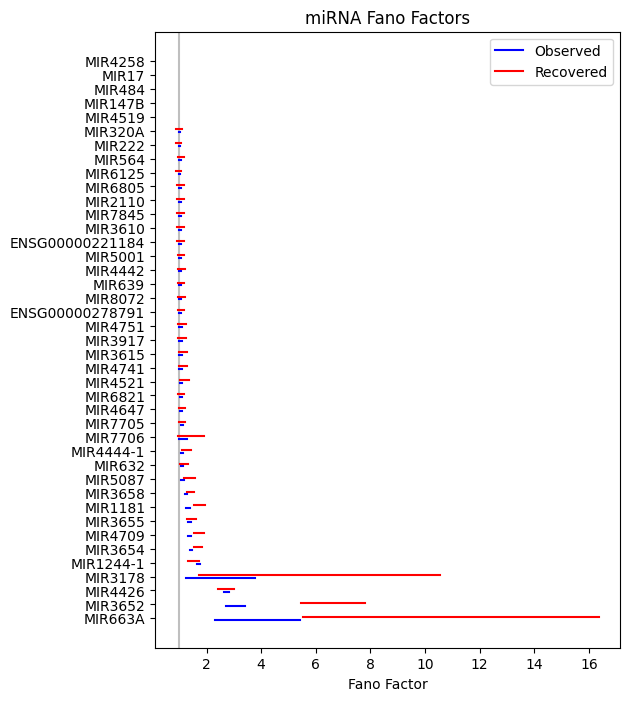

In [92]:
fig, axs = plt.subplots(figsize=(6, 8))

# sort by OB fano factor
fano_df = fano_miRNA_df.copy()
fano_df = fano_df.sort_values(by="c95_OB", ascending=False)

OB_fano_lb = fano_df['c95_OB_min']
OB_fano_ub = fano_df['c95_OB_max']

AL_fano_lb = fano_df['c95_AL_min']
AL_fano_ub = fano_df['c95_AL_max']

G = fano_df.shape[0]

axs.axvline(1, color="grey", alpha=0.5)
axs.plot(
    [OB_fano_lb, OB_fano_ub],
    [
        [i - 0.1 for i in range(G)],
        [i - 0.1 for i in range(G)]
    ],
    color="blue"
);
axs.plot([], [], color="blue", label="Observed")
axs.plot(
    [AL_fano_lb, AL_fano_ub],
    [
        [i + 0.1 for i in range(G)],
        [i + 0.1 for i in range(G)]
    ],
    color="red"
);
axs.plot([], [], color="red", label="Recovered")

axs.set_xlabel("Fano Factor")
axs.set_yticks(range(G))
axs.set_yticklabels(fano_df.index)
axs.set_title("miRNA Fano Factors")
axs.legend()
plt.show()

### mRNA

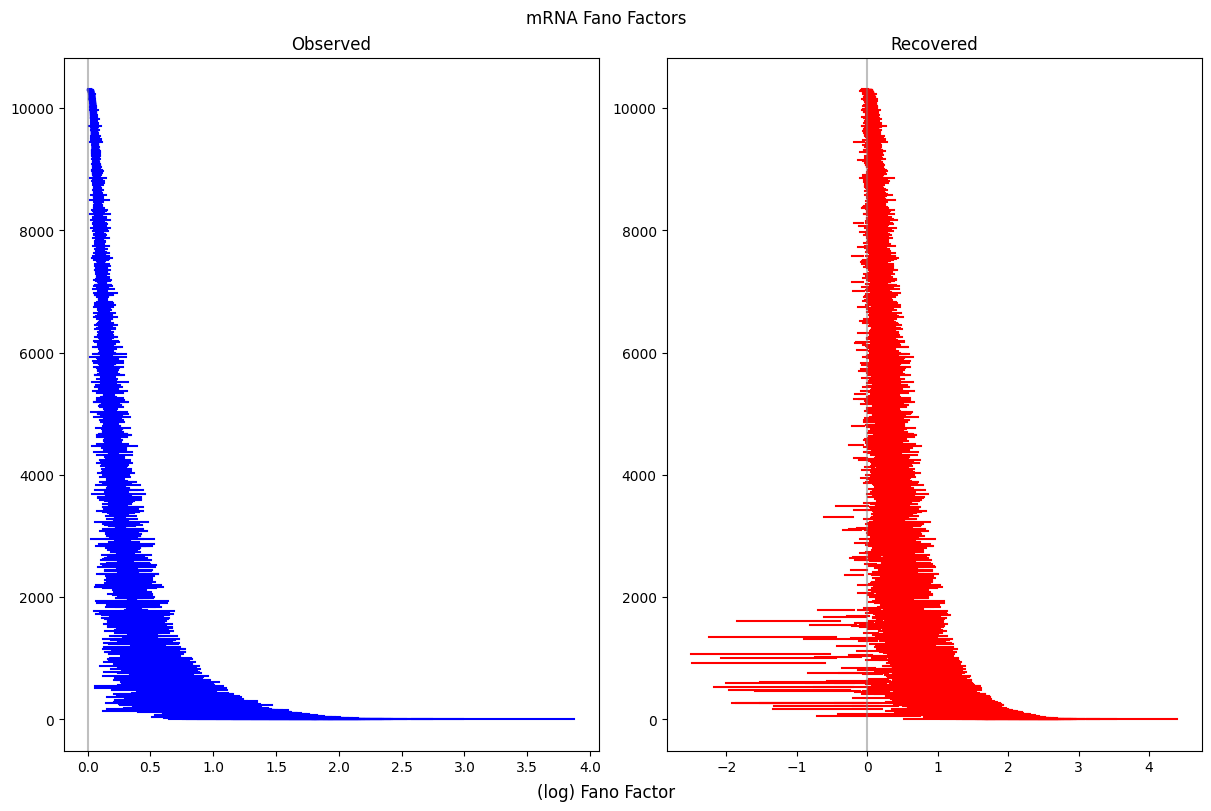

In [93]:
fig, axs = plt.subplots(1, 2, figsize=(12, 8), constrained_layout=True)

# sort by OB fano factor
fano_df = fano_pcRNA_df.copy()
fano_df = fano_df.sort_values(by="c95_OB", ascending=False)

OB_fano_lb = np.log10(fano_df['c95_OB_min'])
OB_fano_ub = np.log10(fano_df['c95_OB_max'])

AL_fano_lb = np.log10(fano_df['c95_AL_min'])
AL_fano_ub = np.log10(fano_df['c95_AL_max'])

G = fano_df.shape[0]

axs[0].plot(
    [OB_fano_lb, OB_fano_ub],
    [
        [i - 0.1 for i in range(G)],
        [i - 0.1 for i in range(G)]
    ],
    color="blue"
);
axs[0].plot([], [], color="blue", label="Observed")
axs[1].plot(
    [AL_fano_lb, AL_fano_ub],
    [
        [i + 0.1 for i in range(G)],
        [i + 0.1 for i in range(G)]
    ],
    color="red"
);
axs[1].plot([], [], color="red", label="Recovered")

axs[0].axvline(np.log10(1), color="grey", alpha=0.5)
axs[1].axvline(np.log10(1), color="grey", alpha=0.5)

#axs.set_yticks(range(G))
#axs.set_yticklabels(fano_df.index)
axs[0].set_title("Observed")
axs[1].set_title("Recovered")
fig.supxlabel("(log) Fano Factor")
fig.suptitle("mRNA Fano Factors")
plt.show()

## Optimization method

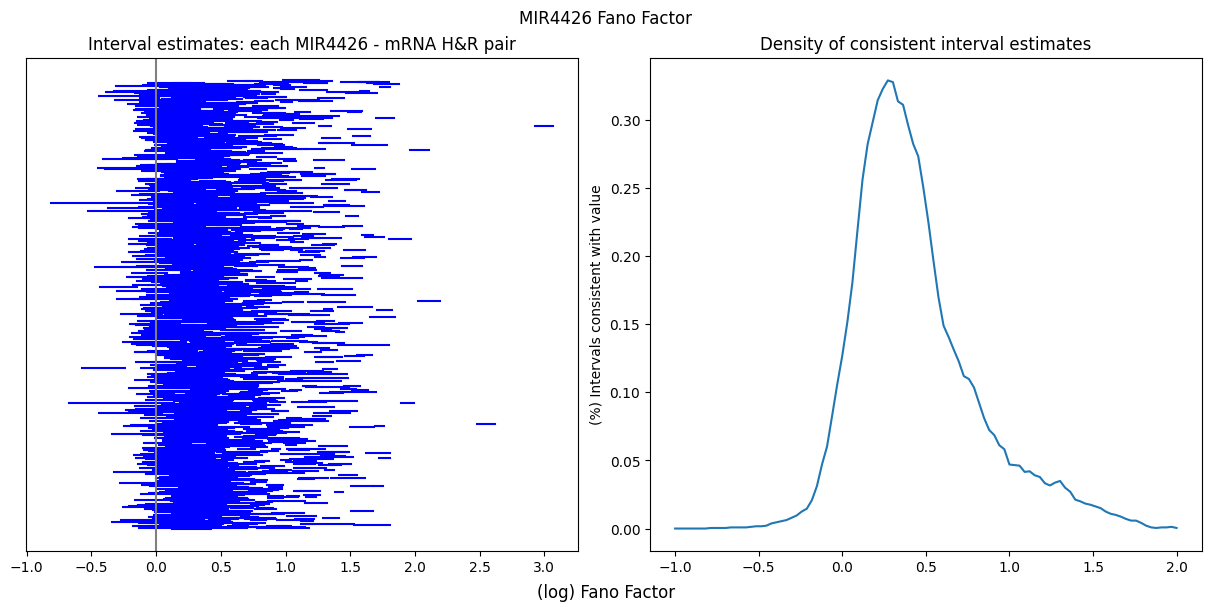

In [73]:
# data
HAR_fano_lb = int_MF_d3_5_df['MIR4426_d3_N1000_c95_mc95_HAR_fano_1_min']
HAR_fano_ub = int_MF_d3_5_df['MIR4426_d3_N1000_c95_mc95_HAR_fano_1_max']
G = HAR_fano_lb.shape[0]

# consistency: overlap of intervals
ts = np.linspace(-1, 2, 100)
ns = []
for t in ts:
    mask = (np.log10(HAR_fano_lb) <= t) & (np.log10(HAR_fano_ub) >= t)
    ns.append(int(mask.sum()) / G)

# plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

axs[0].plot(
    [np.log10(HAR_fano_lb), np.log10(HAR_fano_ub)],
    [[i for i in range(G)], [i for i in range(G)]],
    color="blue"
)
axs[0].axvline(np.log10(1), color="grey")
axs[0].set_title("Interval estimates: each MIR4426 - mRNA H&R pair")
axs[0].set_yticks([])

axs[1].plot(ts, ns)
axs[1].set_title("Density of consistent interval estimates")
axs[1].set_ylabel("(%) Intervals consistent with value")

fig.suptitle("MIR4426 Fano Factor")
fig.supxlabel("(log) Fano Factor")
plt.show()

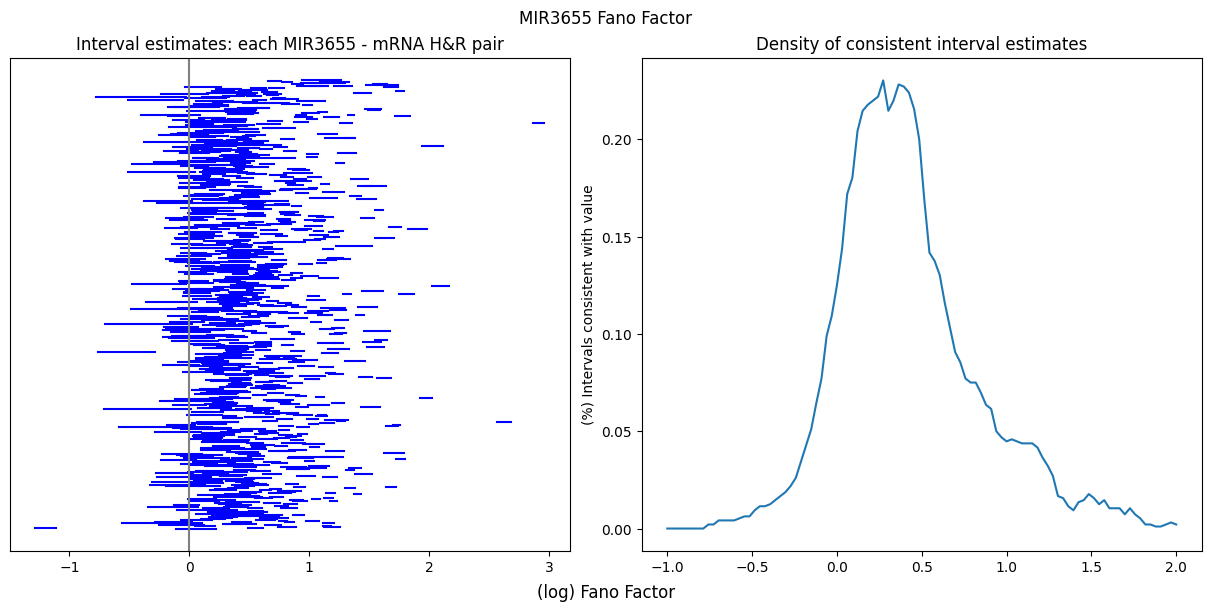

In [75]:
# data
HAR_fano_lb = int_MF_d3_12_df['MIR3655_d3_N1000_c95_mc95_HAR_fano_1_min']
HAR_fano_ub = int_MF_d3_12_df['MIR3655_d3_N1000_c95_mc95_HAR_fano_1_max']
G = HAR_fano_lb.shape[0]

# consistency: overlap of intervals
ts = np.linspace(-1, 2, 100)
ns = []
for t in ts:
    mask = (np.log10(HAR_fano_lb) <= t) & (np.log10(HAR_fano_ub) >= t)
    ns.append(int(mask.sum()) / G)

# plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

axs[0].plot(
    [np.log10(HAR_fano_lb), np.log10(HAR_fano_ub)],
    [[i for i in range(G)], [i for i in range(G)]],
    color="blue"
)
axs[0].axvline(np.log10(1), color="grey")
axs[0].set_title("Interval estimates: each MIR3655 - mRNA H&R pair")
axs[0].set_yticks([])

axs[1].plot(ts, ns)
axs[1].set_title("Density of consistent interval estimates")
axs[1].set_ylabel("(%) Intervals consistent with value")

fig.suptitle("MIR3655 Fano Factor")
fig.supxlabel("(log) Fano Factor")
plt.show()

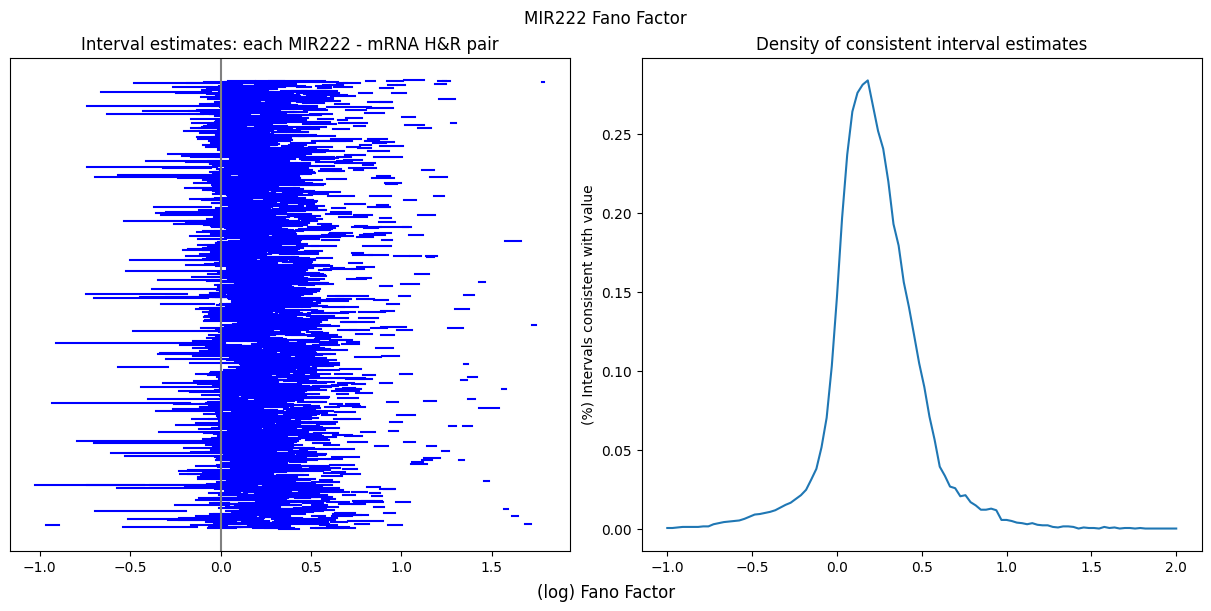

In [76]:
# data
HAR_fano_lb = int_MF_d3_40_df['MIR222_d3_N1000_c95_mc95_HAR_fano_1_min']
HAR_fano_ub = int_MF_d3_40_df['MIR222_d3_N1000_c95_mc95_HAR_fano_1_max']
G = HAR_fano_lb.shape[0]

# consistency: overlap of intervals
ts = np.linspace(-1, 2, 100)
ns = []
for t in ts:
    mask = (np.log10(HAR_fano_lb) <= t) & (np.log10(HAR_fano_ub) >= t)
    ns.append(int(mask.sum()) / G)

# plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

axs[0].plot(
    [np.log10(HAR_fano_lb), np.log10(HAR_fano_ub)],
    [[i for i in range(G)], [i for i in range(G)]],
    color="blue"
)
axs[0].axvline(np.log10(1), color="grey")
axs[0].set_title("Interval estimates: each MIR222 - mRNA H&R pair")
axs[0].set_yticks([])

axs[1].plot(ts, ns)
axs[1].set_title("Density of consistent interval estimates")
axs[1].set_ylabel("(%) Intervals consistent with value")

fig.suptitle("MIR222 Fano Factor")
fig.supxlabel("(log) Fano Factor")
plt.show()

### Separate by correlation

1556


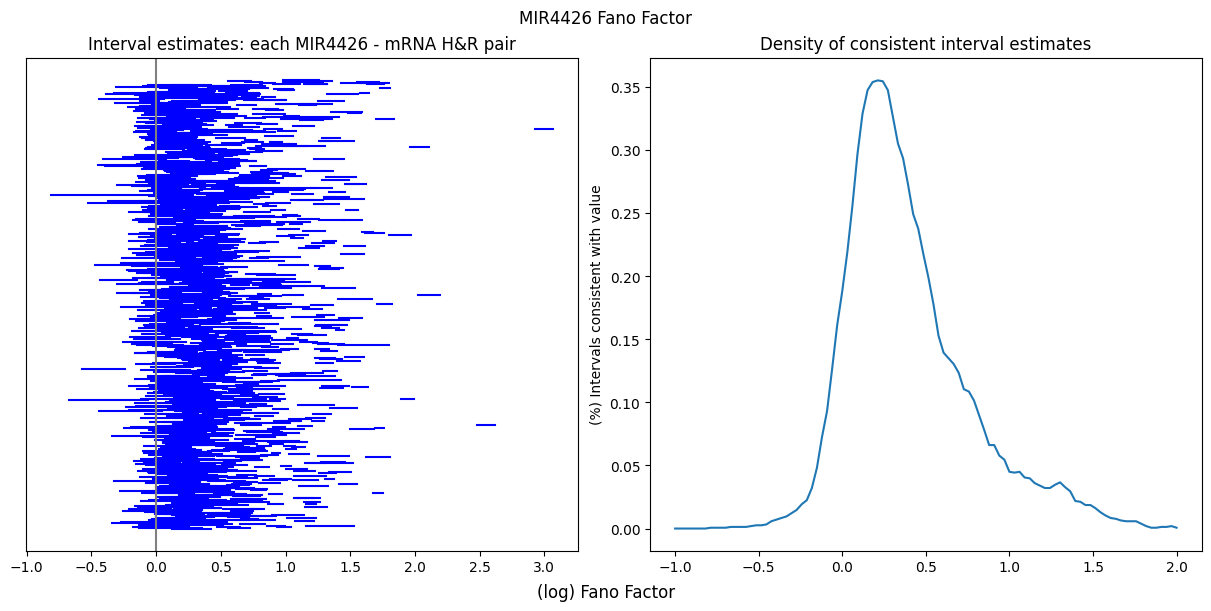

In [79]:
# data
mask = (int_MF_d3_5_df['MIR4426_d3_N1000_c95_mc95_HAR_corr_max'] < 0)
HAR_fano_lb = int_MF_d3_5_df['MIR4426_d3_N1000_c95_mc95_HAR_fano_1_min'][mask]
HAR_fano_ub = int_MF_d3_5_df['MIR4426_d3_N1000_c95_mc95_HAR_fano_1_max'][mask]
G = HAR_fano_lb.shape[0]
print(G)

# consistency: overlap of intervals
ts = np.linspace(-1, 2, 100)
ns = []
for t in ts:
    mask = (np.log10(HAR_fano_lb) <= t) & (np.log10(HAR_fano_ub) >= t)
    ns.append(int(mask.sum()) / G)

# plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

axs[0].plot(
    [np.log10(HAR_fano_lb), np.log10(HAR_fano_ub)],
    [[i for i in range(G)], [i for i in range(G)]],
    color="blue"
)
axs[0].axvline(np.log10(1), color="grey")
axs[0].set_title("Interval estimates: each MIR4426 - mRNA H&R pair")
axs[0].set_yticks([])

axs[1].plot(ts, ns)
axs[1].set_title("Density of consistent interval estimates")
axs[1].set_ylabel("(%) Intervals consistent with value")

fig.suptitle("MIR4426 Fano Factor")
fig.supxlabel("(log) Fano Factor")
plt.show()

850


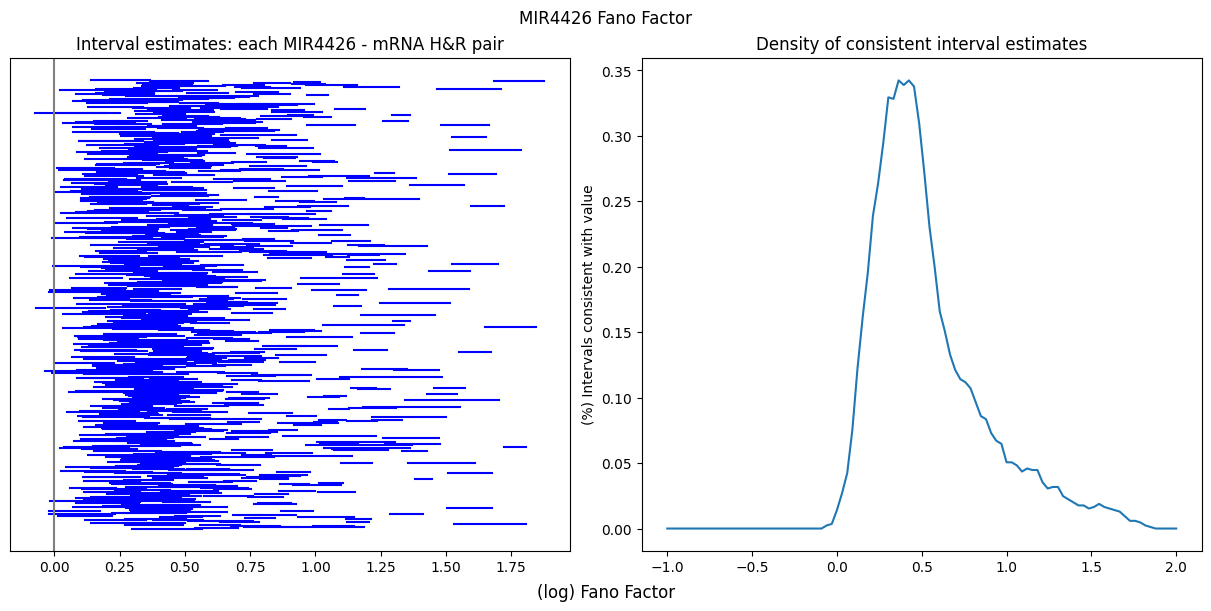

In [89]:
# data
mask = (int_MF_d3_5_df['MIR4426_d3_N1000_c95_mc95_HAR_corr_max'] < 0)
HAR_fano_lb = int_MF_d3_5_df['MIR4426_d3_N1000_c95_mc95_HAR_fano_1_min'][~mask]
HAR_fano_ub = int_MF_d3_5_df['MIR4426_d3_N1000_c95_mc95_HAR_fano_1_max'][~mask]
G = HAR_fano_lb.shape[0]
print(G)

# consistency: overlap of intervals
ts = np.linspace(-1, 2, 100)
ns = []
for t in ts:
    mask = (np.log10(HAR_fano_lb) <= t) & (np.log10(HAR_fano_ub) >= t)
    ns.append(int(mask.sum()) / G)

# plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

axs[0].plot(
    [np.log10(HAR_fano_lb), np.log10(HAR_fano_ub)],
    [[i for i in range(G)], [i for i in range(G)]],
    color="blue"
)
axs[0].axvline(np.log10(1), color="grey")
axs[0].set_title("Interval estimates: each MIR4426 - mRNA H&R pair")
axs[0].set_yticks([])

axs[1].plot(ts, ns)
axs[1].set_title("Density of consistent interval estimates")
axs[1].set_ylabel("(%) Intervals consistent with value")

fig.suptitle("MIR4426 Fano Factor")
fig.supxlabel("(log) Fano Factor")
plt.show()

# Interaction Graphs

In [14]:
from wolframclient.evaluation import WolframLanguageSession
from wolframclient.language import wl
from PIL import Image
import io

In [15]:
# start session
session = WolframLanguageSession(r'C:\Program Files\Wolfram Research\Wolfram\14.3\SystemFiles\Kernel\Binaries\Windows-x86-64/WolframKernel.exe')

In [16]:
# select miRNA
miRNA_list = ["MIR4426", "MIR3655", "MIR222"]
df_ind = pd.concat([ind_MF_5_df, ind_MF_12_df, ind_MF_40_df], axis="columns")

# select mRNA via recovered correlation (AL) as a filter
df_cor = pd.concat([corr_5_df['MIR4426_c95_AL'], corr_12_df['MIR3655_c95_AL'], corr_40_df['MIR222_c95_AL']], axis="columns")
mask = (df_cor >= -1) & (df_cor <= -0.2)
mask = (mask.sum(axis=1) >= 3).values
df_ind = df_ind[mask]

# select mRNA with more than n interactions
mask = ((df_ind == "INFEASIBLE").sum(axis=1) >= 1).values
df_ind = df_ind[mask]

# drop duplicates indices?
#df_ind = df_ind[~df_ind.index.duplicated()]

print(df_ind.shape)

(87, 3)


In [17]:
# construct incidence matrix from interaction pairs
edges = []
for i, miRNA in enumerate(miRNA_list):
    for j, mRNA in enumerate(df_ind.index):
        if df_ind.iloc[j, i] == "INFEASIBLE":
            a1 = [0] * df_ind.shape[1]
            a1[i] = 1 # -1 makes directed
            a2 = [0] * df_ind.shape[0]
            a2[j] = 1
            edge = np.array(a1 + a2)
            edges.append(edge)

incidence_matrix = np.vstack(edges).T

In [18]:
# python labels (miRNA)
vertex_labels = miRNA_list + [""] * df_ind.shape[0] # list(df_ind.index)
vertex_colors = [wl.Red for _ in miRNA_list] + [wl.Blue for _ in df_ind.index]

# convert to mathematica
vertex_labels_ma = [wl.Rule(i + 1, name) for i, name in enumerate(vertex_labels)]
vertex_colors_ma = [wl.Rule(i + 1, color) for i, color in enumerate(vertex_colors)]
vertex_size_ma = [wl.Rule(i + 1, wl.Large) if i < len(miRNA_list) else wl.Rule(i + 1, wl.Small) for i, _ in enumerate(vertex_labels)]

# construct graph
matrix_list = incidence_matrix.tolist()
graph_expr = wl.IncidenceGraph(
    matrix_list,
    VertexLabels=vertex_labels_ma,
    VertexLabelStyle=wl.Directive(wl.Black, wl.Bold, wl.Large),
    VertexSize=vertex_size_ma, #wl.Medium,
    VertexStyle=vertex_colors_ma,
    EdgeStyle=wl.Opacity(0.1)
)

# construct plot
plot_expr = wl.Graph(
    graph_expr,
    wl.Rule("ImageSize", 1000),
    wl.Rule("PerformanceGoal", "Speed"), # Quality
    #wl.Rule("GraphLayout", "BipartiteEmbedding"),
    wl.Rule("Background", wl.White),
)

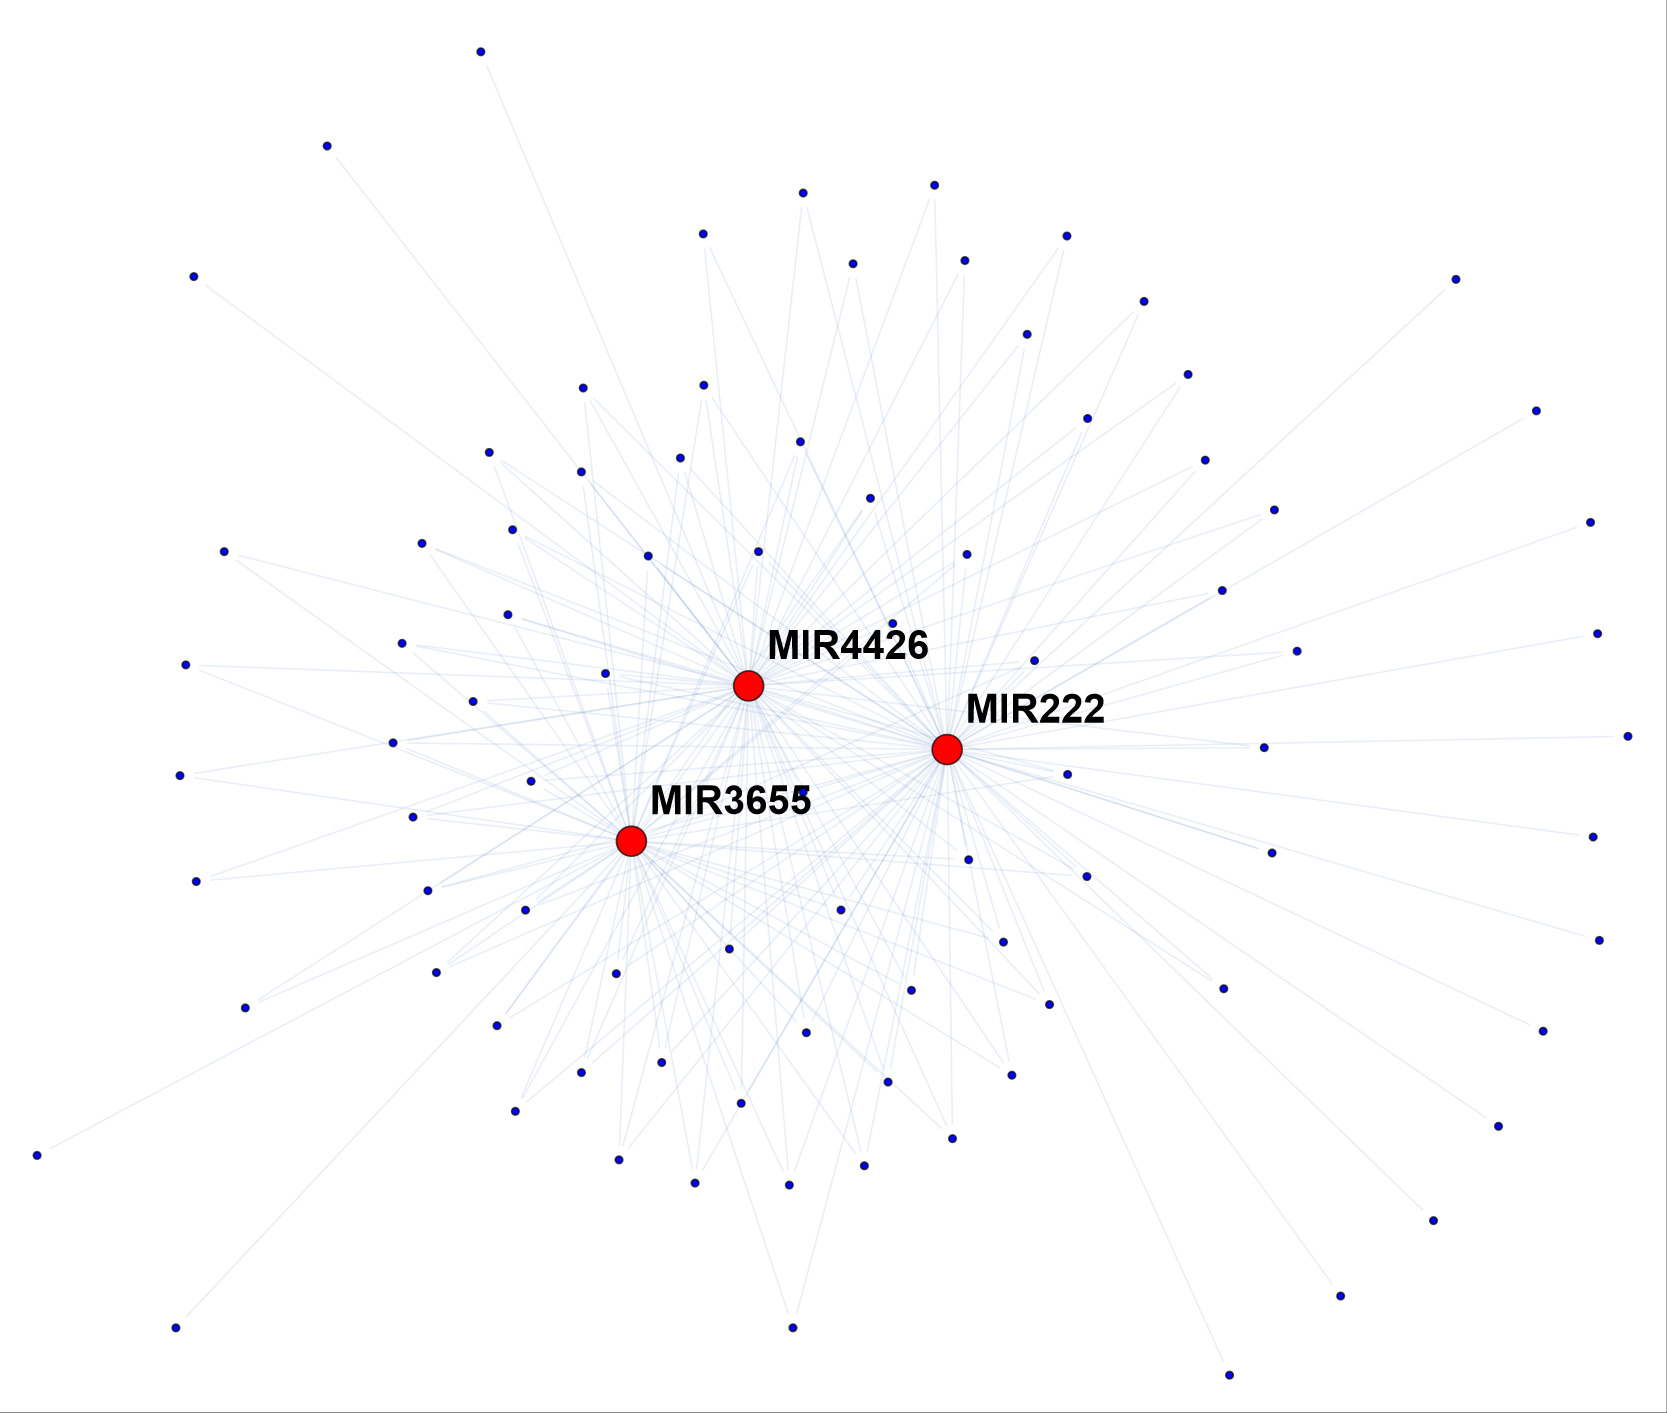

In [19]:
# display
img_data=session.evaluate(wl.ExportByteArray(plot_expr, 'PNG'))
Image.open(io.BytesIO(img_data))

In [ ]:
# save
output_path = "mathematica_graph.png"
#session.evaluate(wl.Export(output_path, plot_expr))

In [ ]:
# end session
#session.terminate()

# Model results

## MIR4426

In [42]:
BD_d3_5_df.value_counts()

MIR4426_d3_c95_status
OPTIMAL                  1238
INFEASIBLE               1168
Name: count, dtype: int64

In [45]:
TE_d3_5_df.value_counts()

MIR4426_d3_c95_status
OPTIMAL                  905
CUT_LIMIT                132
TIME_LIMIT               131
Name: count, dtype: int64

### d = 2

In [48]:
BD_d2_5_df.value_counts()

MIR4426_d2_c95_status
OPTIMAL                  2241
INFEASIBLE                  5
CUT_LIMIT                   1
Name: count, dtype: int64

In [50]:
TE_d2_5_df.value_counts()

MIR4426_d2_c95_status
INFEASIBLE               5
Name: count, dtype: int64

## MIR3655

In [43]:
BD_d3_12_df.value_counts()

MIR3655_d3_c95_status
OPTIMAL                  555
INFEASIBLE               403
TIME_LIMIT                 2
Name: count, dtype: int64

In [46]:
TE_d3_12_df.value_counts()

MIR3655_d3_c95_status
OPTIMAL                  302
TIME_LIMIT                52
CUT_LIMIT                 49
Name: count, dtype: int64

## MIR222

In [44]:
BD_d3_40_df.value_counts()

MIR222_d3_c95_status
OPTIMAL                 2931
INFEASIBLE                 6
Name: count, dtype: int64

In [ ]:
# unsure why infeasible: as no positive correlations recovered here
TE_d3_40_df.value_counts()

MIR222_d3_c95_status
INFEASIBLE              4
TIME_LIMIT              2
Name: count, dtype: int64

# Exploring Positive miRNA - mRNA Correlation

Look at
- expression levels
- gene ontology
- correlation between mRNA (maybe move AL code from scipt_running here)

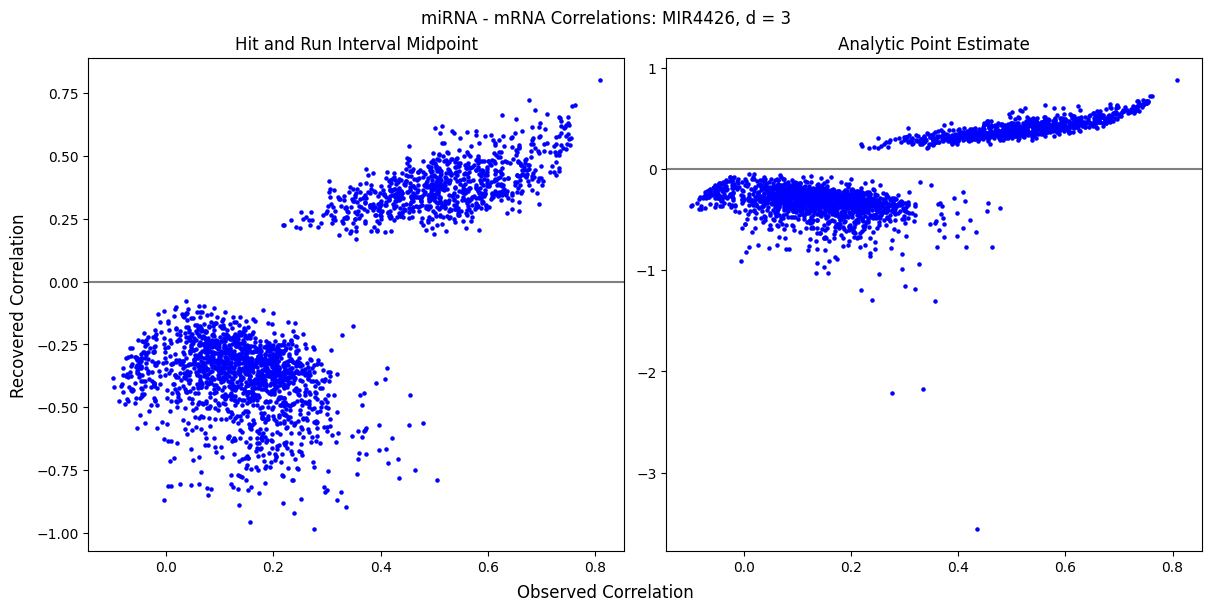

In [229]:
# data
ind_df = ind_MF_d3_5_df
int_df = int_MF_d3_5_df
corr_df = corr_5_df
d = 3

# name
miRNA = miRNA_index[5]

# HAR
lb = int_df[f'{miRNA}_d{d}_N1000_c95_mc95_HAR_corr_min']
ub = int_df[f'{miRNA}_d{d}_N1000_c95_mc95_HAR_corr_max']
mid = (lb + ub) / 2

# OB & AL
mask = (ind_df == "INFEASIBLE").values.squeeze()
OB = corr_df[f'{miRNA}_c95_OB'][mask]
AL = corr_df[f'{miRNA}_c95_AL'][mask]

# stats
HAR_neg = int((mid < 0).sum())
HAR_pos = int((mid > 0).sum())
AL_neg = int((AL < 0).sum())
AL_pos = int((AL > 0).sum())

# plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
axs[0].scatter(OB, mid, color="blue", s=5, label=fr"{HAR_neg} $\rho$ < 0 | {HAR_pos} $\rho$ > 0")
axs[0].axhline(0, color="grey")
axs[1].scatter(OB, AL, color="blue", s=5, label=fr"{AL_neg} $\rho$ < 0 | {AL_pos} $\rho$ > 0")
axs[1].axhline(0, color="grey")
axs[0].set_title("Hit and Run Interval Midpoint")
axs[1].set_title("Analytic Point Estimate")
fig.suptitle(f"miRNA - mRNA Correlations: {miRNA}, d = {d}")
fig.supylabel("Recovered Correlation")
fig.supxlabel("Observed Correlation")
plt.show()

## Expression levels

In [230]:
import anndata as ad

In [231]:
# load miRNA
adata_miRNA = ad.read_h5ad("TotalX_HEK293T_miRNA.h5ad")

# load pcRNA
adata_pcRNA = ad.read_h5ad("TotalX_HEK293T_pcRNA.h5ad")

# load capture
beta = np.loadtxt("TotalX_HEK293T_capture.txt")

In [232]:
# names of mRNA with positive recovered correlation to miRNA (H&R midpoint)
names_pos = mid[mid > 0].index

# negative recovered correlation
names_neg = mid[mid < 0].index

# subset adata to these
adata_pos = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_pos)]
adata_neg = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_neg)]

In [233]:
# subset all independent mRNA
names_int = mid.index
adata_ind = adata_pcRNA[:, ~adata_pcRNA.var['GeneName'].isin(names_int)]

In [234]:
# compute mean expression level (observed)
mean_expression_pos = np.asarray(adata_pos.X.mean(axis=0)).squeeze()
mean_expression_neg = np.asarray(adata_neg.X.mean(axis=0)).squeeze()
mean_expression_ind = np.asarray(adata_ind.X.mean(axis=0)).squeeze()

In [235]:
# compute miRNA mean expression level (observed)
mean_expression_miRNA = np.asarray(adata_miRNA[:, 5].X.mean(axis=0)).squeeze()

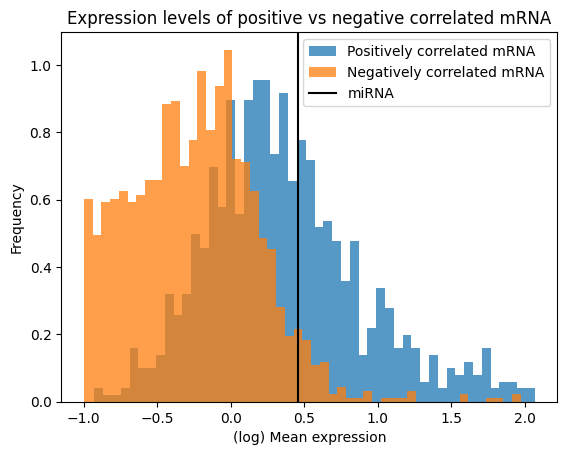

In [236]:
fig, axs = plt.subplots()
axs.hist(np.log10(mean_expression_pos), density=True, alpha=0.75, bins=50, label="Positively correlated mRNA");
axs.hist(np.log10(mean_expression_neg), density=True, alpha=0.75, bins=50, label="Negatively correlated mRNA");
#axs.hist(np.log10(mean_expression_ind), density=True, alpha=0.25, bins=100, label="Independent mRNA");
axs.axvline(np.log10(mean_expression_miRNA), color="black", label=f"miRNA")
axs.set_xlabel("(log) Mean expression")
axs.set_ylabel("Frequency")
axs.set_title("Expression levels of positive vs negative correlated mRNA")
axs.legend()
plt.show()

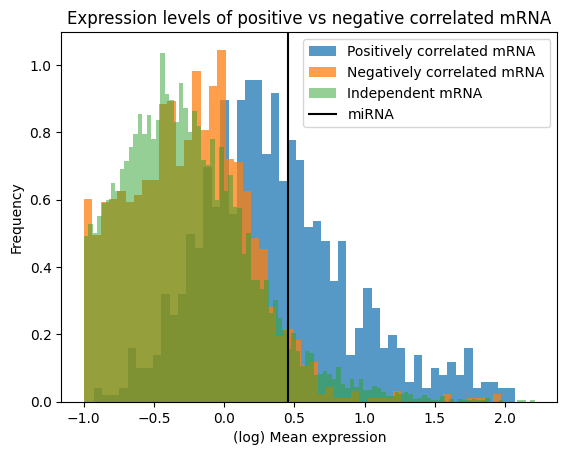

In [237]:
fig, axs = plt.subplots()
axs.hist(np.log10(mean_expression_pos), density=True, alpha=0.75, bins=50, label="Positively correlated mRNA");
axs.hist(np.log10(mean_expression_neg), density=True, alpha=0.75, bins=50, label="Negatively correlated mRNA");
axs.hist(np.log10(mean_expression_ind), density=True, alpha=0.5, bins=100, label="Independent mRNA");
axs.axvline(np.log10(mean_expression_miRNA), color="black", label=f"miRNA")
axs.set_xlabel("(log) Mean expression")
axs.set_ylabel("Frequency")
axs.set_title("Expression levels of positive vs negative correlated mRNA")
axs.legend()
plt.show()

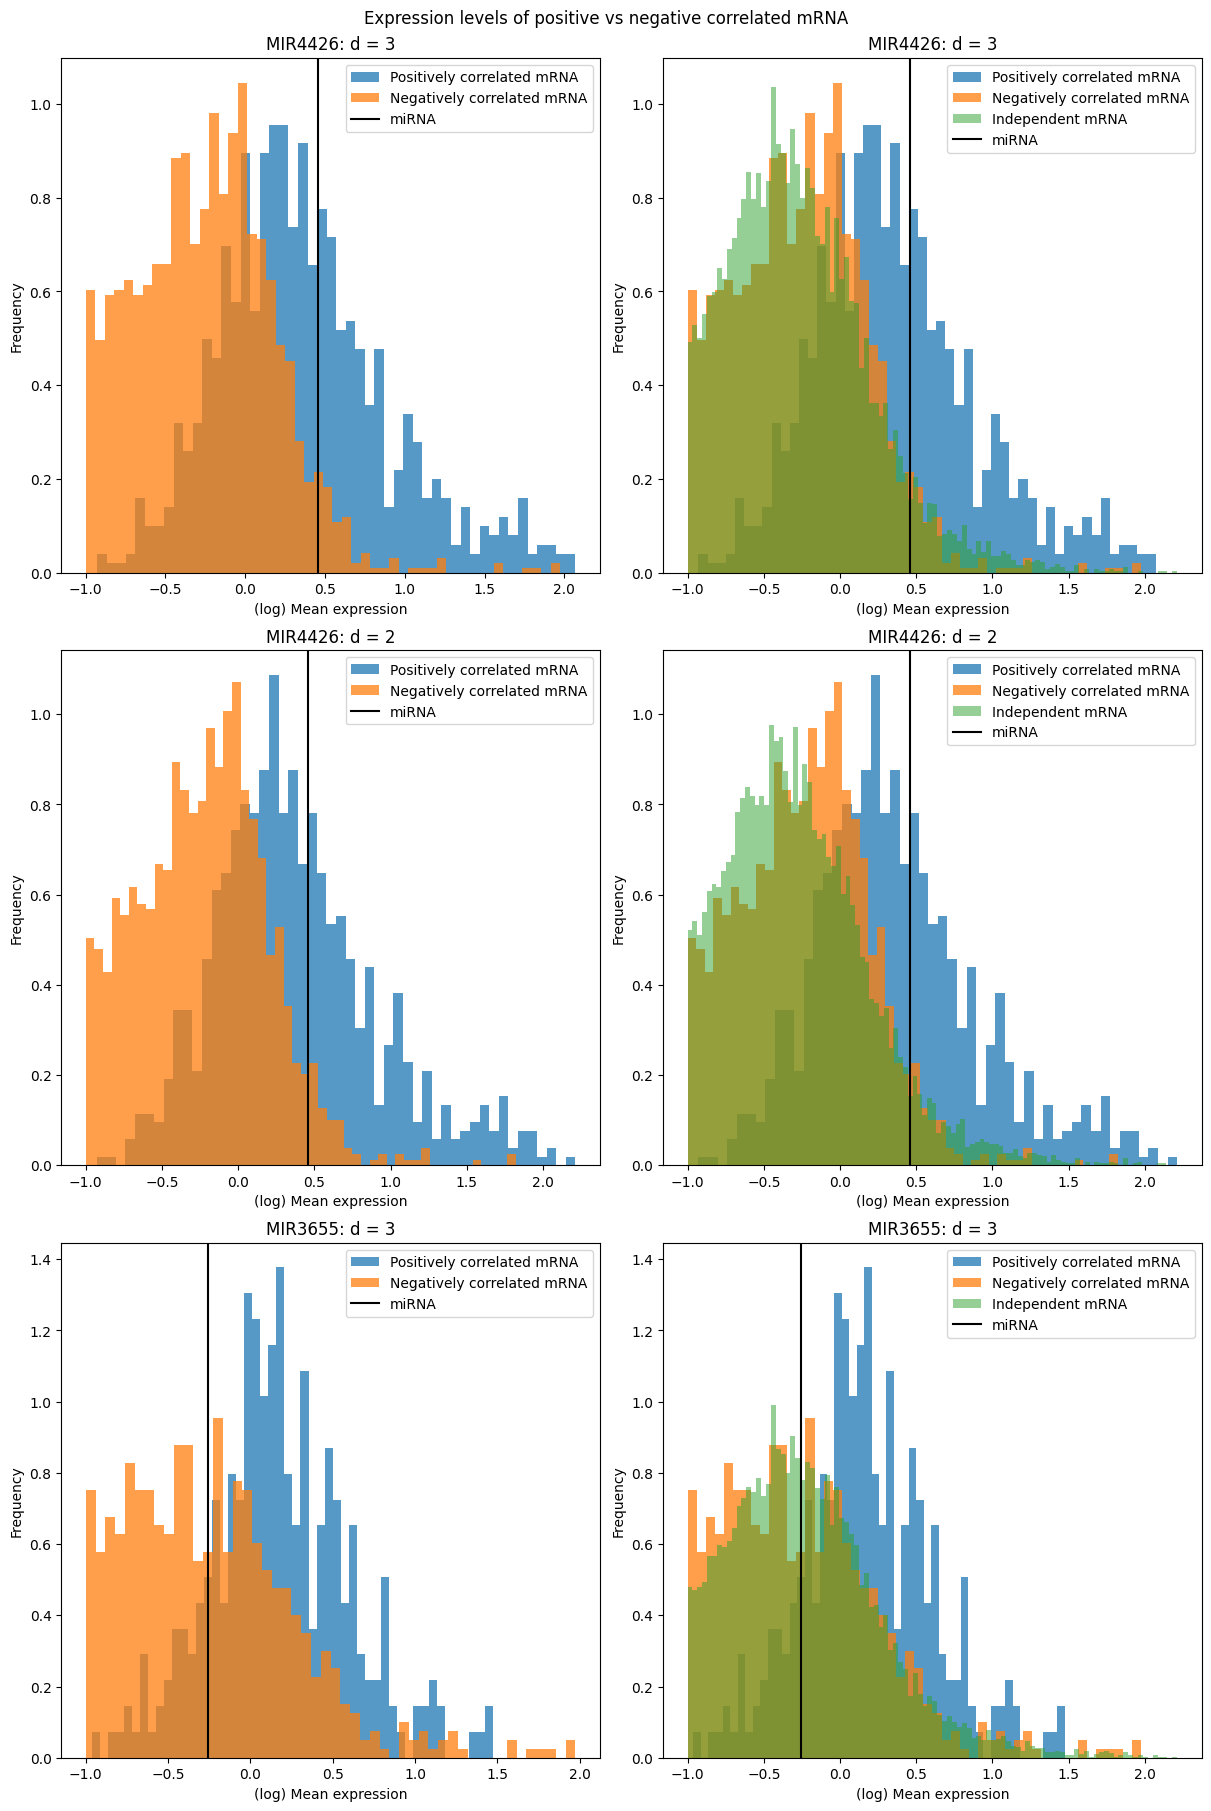

In [241]:
# data
ind_df = ind_MF_d3_5_df
int_df = int_MF_d3_5_df
corr_df = corr_5_df
d = 3

ind_df_list = [ind_MF_d3_5_df, ind_MF_d2_5_df, ind_MF_d3_12_df]
int_df_list = [int_MF_d3_5_df, int_MF_d2_5_df, int_MF_d3_12_df]
corr_df_list = [corr_5_df, corr_5_df, corr_12_df]
miRNA_idx_list = [5, 5, 12]
d_list = [3, 2, 3]

fig, axs = plt.subplots(3, 2, figsize=(12, 18), constrained_layout=True)

for i, (ind_df, int_df, corr_df, miRNA_idx, d) in enumerate(zip(ind_df_list, int_df_list, corr_df_list, miRNA_idx_list, d_list)):

    # miRNA
    miRNA = miRNA_index[miRNA_idx]

    # HAR
    lb = int_df[f'{miRNA}_d{d}_N1000_c95_mc95_HAR_corr_min']
    ub = int_df[f'{miRNA}_d{d}_N1000_c95_mc95_HAR_corr_max']
    mid = (lb + ub) / 2

    # names of mRNA with positive recovered correlation to miRNA (H&R midpoint)
    names_pos = mid[mid > 0].index

    # negative recovered correlation
    names_neg = mid[mid < 0].index

    # subset adata to these
    adata_pos = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_pos)]
    adata_neg = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_neg)]

    # subset all independent mRNA
    names_int = mid.index
    adata_ind = adata_pcRNA[:, ~adata_pcRNA.var['GeneName'].isin(names_int)]

    # compute mean expression level (observed)
    mean_expression_pos = np.asarray(adata_pos.X.mean(axis=0)).squeeze()
    mean_expression_neg = np.asarray(adata_neg.X.mean(axis=0)).squeeze()
    mean_expression_ind = np.asarray(adata_ind.X.mean(axis=0)).squeeze()

    # compute miRNA mean expression level (observed)
    mean_expression_miRNA = np.asarray(adata_miRNA[:, miRNA_idx].X.mean(axis=0)).squeeze()

    for j in range(2):
        axs[i, j].hist(np.log10(mean_expression_pos), density=True, alpha=0.75, bins=50, label="Positively correlated mRNA");
        axs[i, j].hist(np.log10(mean_expression_neg), density=True, alpha=0.75, bins=50, label="Negatively correlated mRNA");
        if j == 1: axs[i, j].hist(np.log10(mean_expression_ind), density=True, alpha=0.5, bins=100, label="Independent mRNA");
        axs[i, j].axvline(np.log10(mean_expression_miRNA), color="black", label=f"miRNA")
        axs[i, j].set_xlabel("(log) Mean expression")
        axs[i, j].set_ylabel("Frequency")
        axs[i, j].set_title(f"{miRNA}: d = {d}")
        axs[i, j].legend()

fig.suptitle("Expression levels of positive vs negative correlated mRNA")
plt.show()

## Gene Ontology

MIR4426
- positive: https://biit.cs.ut.ee/gplink/l/aZVtmzBCvSA
    - threshold: https://biit.cs.ut.ee/gplink/l/abez_s76eTl (0.5)
- negative: https://biit.cs.ut.ee/gplink/l/aXbx2oWpVS4
    - threshold: https://biit.cs.ut.ee/gplink/l/abez_s76eTl (0.5)

- ordered
    - positive: https://biit.cs.ut.ee/gplink/l/a1qTFYrmkQM
    - negative: https://biit.cs.ut.ee/gplink/l/akA0w7QMhRW

MIR3655
- positive: https://biit.cs.ut.ee/gplink/l/aD1B7zKPoRE
    - threshold: https://biit.cs.ut.ee/gplink/l/aDrU3ZfSdT9 (0.25)
- negative: https://biit.cs.ut.ee/gplink/l/aCpAv2qBPRb
    - threshold: https://biit.cs.ut.ee/gplink/l/aX7qjJIZSRq (0.25)
 
MIR222
- negative: https://biit.cs.ut.ee/gplink/l/a229514_URc
    - threshold: https://biit.cs.ut.ee/gplink/l/aUSvaRHBKSo (0.5)


In [8]:
import anndata as ad

In [9]:
# load miRNA
adata_miRNA = ad.read_h5ad("TotalX_HEK293T_miRNA.h5ad")

# load pcRNA
adata_pcRNA = ad.read_h5ad("TotalX_HEK293T_pcRNA.h5ad")

# load capture
beta = np.loadtxt("TotalX_HEK293T_capture.txt")

In [41]:
# select data
ind_df = ind_MF_d3_40_df
int_df = int_MF_d3_40_df
corr_df = corr_40_df
d = 3
miRNA = miRNA_index[40]
print(miRNA)

# HAR
lb = int_df[f'{miRNA}_d{d}_N1000_c95_mc95_HAR_corr_min']
ub = int_df[f'{miRNA}_d{d}_N1000_c95_mc95_HAR_corr_max']
mid = (lb + ub) / 2

# names of mRNA with positive recovered correlation to miRNA (H&R midpoint)
names_pos = mid[mid > 0].index

# negative recovered correlation
names_neg = mid[mid < 0].index

# subset adata to these
adata_pos = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_pos)]
adata_neg = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_neg)]

MIR222


In [42]:
' '.join(adata_pos.var['gene_ids'].values.tolist())

''

In [43]:
' '.join(adata_neg.var['gene_ids'].values.tolist())

'ENSG00000188976 ENSG00000242485 ENSG00000197785 ENSG00000160075 ENSG00000078369 ENSG00000116151 ENSG00000157916 ENSG00000116198 ENSG00000198912 ENSG00000131697 ENSG00000041988 ENSG00000171735 ENSG00000142599 ENSG00000178585 ENSG00000162441 ENSG00000130939 ENSG00000142657 ENSG00000142655 ENSG00000198793 ENSG00000116688 ENSG00000116731 ENSG00000189337 ENSG00000116786 ENSG00000233954 ENSG00000065526 ENSG00000090686 ENSG00000070831 ENSG00000004487 ENSG00000169641 ENSG00000125944 ENSG00000007968 ENSG00000142676 ENSG00000117305 ENSG00000189266 ENSG00000188529 ENSG00000001460 ENSG00000133226 ENSG00000169504 ENSG00000117614 ENSG00000127423 ENSG00000198830 ENSG00000117713 ENSG00000142751 ENSG00000090273 ENSG00000142784 ENSG00000009780 ENSG00000126698 ENSG00000130770 ENSG00000130766 ENSG00000204138 ENSG00000116350 ENSG00000084628 ENSG00000121766 ENSG00000121774 ENSG00000025800 ENSG00000084652 ENSG00000160050 ENSG00000176261 ENSG00000162521 ENSG00000162520 ENSG00000134684 ENSG00000116497 ENSG000

In [44]:
# threshold to higher correlations
thresh = 0.5
names_pos_thresh = mid[mid > thresh].index
names_neg_thresh = mid[mid < -thresh].index

# subset adata to these
adata_pos_thresh = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_pos_thresh)]
adata_neg_thresh = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_neg_thresh)]

In [45]:
' '.join(adata_pos_thresh.var['gene_ids'].values.tolist())

''

In [46]:
' '.join(adata_neg_thresh.var['gene_ids'].values.tolist())

'ENSG00000171735 ENSG00000070831 ENSG00000198830 ENSG00000162521 ENSG00000092853 ENSG00000054118 ENSG00000142937 ENSG00000174021 ENSG00000177954 ENSG00000143158 ENSG00000182004 ENSG00000171848 ENSG00000228474 ENSG00000243147 ENSG00000213639 ENSG00000143977 ENSG00000034510 ENSG00000158417 ENSG00000155368 ENSG00000077380 ENSG00000154518 ENSG00000119013 ENSG00000144580 ENSG00000172428 ENSG00000232112 ENSG00000168273 ENSG00000163634 ENSG00000184220 ENSG00000138495 ENSG00000174891 ENSG00000169020 ENSG00000138814 ENSG00000109475 ENSG00000109390 ENSG00000121211 ENSG00000145592 ENSG00000164182 ENSG00000123219 ENSG00000228716 ENSG00000169567 ENSG00000164405 ENSG00000177733 ENSG00000113068 ENSG00000113712 ENSG00000164587 ENSG00000177556 ENSG00000164466 ENSG00000169045 ENSG00000231500 ENSG00000111832 ENSG00000272047 ENSG00000106399 ENSG00000196683 ENSG00000164548 ENSG00000122565 ENSG00000006625 ENSG00000132432 ENSG00000106153 ENSG00000243317 ENSG00000253729 ENSG00000176731 ENSG00000164985 ENSG000

### Ordered query

In [ ]:
# select data
ind_df = ind_MF_d3_5_df
int_df = int_MF_d3_5_df
corr_df = corr_5_df
d = 3
miRNA = miRNA_index[5]
print(miRNA)

# HAR
lb = int_df[f'{miRNA}_d{d}_N1000_c95_mc95_HAR_corr_min']
ub = int_df[f'{miRNA}_d{d}_N1000_c95_mc95_HAR_corr_max']
mid = (lb + ub) / 2

# names of mRNA with positive recovered correlation to miRNA (H&R midpoint)
names_pos = mid[mid > 0].index

# negative recovered correlation
names_neg = mid[mid < 0].index

# subset adata to these
adata_pos = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_pos)]
adata_neg = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_neg)]

# extract gene IDs
df_pos = adata_pos.var[['gene_ids', 'GeneName']]
df_neg = adata_neg.var[['gene_ids', 'GeneName']]
df_pos = df_pos.set_index('GeneName')
df_neg = df_neg.set_index('GeneName')

# add correlation
df_pos['corr'] = mid[mid > 0]
df_neg['corr'] = mid[mid < 0]

# sort by decreasing correlation size
df_pos = df_pos.sort_values(by="corr", ascending=False)
df_neg = df_neg.sort_values(by="corr", ascending=True)

MIR4426


In [93]:
' '.join(df_pos['gene_ids'].values.tolist())

'ENSG00000143947 ENSG00000152795 ENSG00000171863 ENSG00000071082 ENSG00000111716 ENSG00000204628 ENSG00000173207 ENSG00000174748 ENSG00000063177 ENSG00000105640 ENSG00000087302 ENSG00000241343 ENSG00000147604 ENSG00000134419 ENSG00000161970 ENSG00000108298 ENSG00000198242 ENSG00000166851 ENSG00000100836 ENSG00000149273 ENSG00000196262 ENSG00000142676 ENSG00000175063 ENSG00000105193 ENSG00000007080 ENSG00000131475 ENSG00000167085 ENSG00000170540 ENSG00000164611 ENSG00000204316 ENSG00000164587 ENSG00000163159 ENSG00000124614 ENSG00000115364 ENSG00000134057 ENSG00000167526 ENSG00000123975 ENSG00000114942 ENSG00000117450 ENSG00000185651 ENSG00000145741 ENSG00000112081 ENSG00000198755 ENSG00000116459 ENSG00000163541 ENSG00000136888 ENSG00000138326 ENSG00000115268 ENSG00000165502 ENSG00000090263 ENSG00000149923 ENSG00000168653 ENSG00000117399 ENSG00000109971 ENSG00000213619 ENSG00000204220 ENSG00000148303 ENSG00000156411 ENSG00000163682 ENSG00000198034 ENSG00000143933 ENSG00000108106 ENSG000

In [94]:
' '.join(df_neg['gene_ids'].values.tolist())

'ENSG00000124193 ENSG00000168036 ENSG00000144580 ENSG00000130741 ENSG00000181350 ENSG00000138814 ENSG00000106823 ENSG00000092853 ENSG00000146457 ENSG00000074855 ENSG00000143153 ENSG00000169045 ENSG00000198899 ENSG00000164548 ENSG00000141510 ENSG00000088448 ENSG00000152457 ENSG00000182197 ENSG00000198625 ENSG00000186153 ENSG00000101126 ENSG00000125850 ENSG00000228253 ENSG00000184903 ENSG00000162520 ENSG00000092470 ENSG00000165304 ENSG00000176390 ENSG00000049618 ENSG00000111832 ENSG00000107077 ENSG00000109133 ENSG00000119969 ENSG00000144724 ENSG00000145996 ENSG00000043093 ENSG00000161888 ENSG00000176871 ENSG00000143443 ENSG00000171848 ENSG00000164776 ENSG00000156802 ENSG00000198938 ENSG00000188559 ENSG00000145495 ENSG00000182985 ENSG00000172493 ENSG00000188312 ENSG00000051825 ENSG00000265808 ENSG00000101911 ENSG00000113569 ENSG00000009780 ENSG00000276043 ENSG00000284526 ENSG00000164466 ENSG00000158604 ENSG00000184349 ENSG00000064651 ENSG00000156299 ENSG00000164808 ENSG00000278619 ENSG000

In [18]:
adata_pcRNA[:, adata_pcRNA.var['GeneName'].str.contains("mir")].var

,gene_ids,feature_types,genome,GeneName,gene_id,biotype
